# **PREPROCESSING & CLEANUP NOTEBOOK**

---
# **1 - NOTEBOOK OBJECTIVE AND STRATEGY**

### 1.1 - PURPOSE OF THIS NOTEBOOK
Explain that the goal is to:

- clean and standardize the dataset
- compute time-series quality metrics
- explore filtering strategies
- generate multiple interim datasets for modeling experimentation

### 1.2 - DATASET VERSIONING PHILOSOPHY
Explain why multiple dataset variants are exported:

- forecasting vs decline detection
- strict vs broad filtering
- geographic subsets
- unit comparability issues

### 1.3 - STRUCTURE OF THE NOTEBOOK
Short explanation of the pipeline:

1. Load and inspect data
2. Clean metadata and columns
3. Build time-series quality indicators
4. Explore data quality visually
5. Define filtering policies
6. Export dataset variants
7. Track dataset versions

---
# **2 - LOAD AND INSPECT RAW DATASET**

### 2.1 - LOAD RAW DATASET

In this section, we load the raw WWF Living Planet Database file and create an initial working copy for preprocessing.

Goals:
- define reproducible file paths
- load the dataset safely
- inspect the first rows
- preserve the raw import before any transformations

In [1]:
# ============================================
# 2.1 Load Raw Dataset
# ============================================

from pathlib import Path
import pandas as pd
import numpy as np

# Display settings for easier inspection
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

# Project paths
PROJECT_ROOT = Path.cwd().parent  # adjust if needed depending on notebook location
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"

# Create interim folder if it doesn't exist
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

# Raw file path
RAW_FILE = RAW_DIR / "WWF_LPD_2024_public.csv"  # change to actual filename if needed

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_FILE)
print("Interim path:", INTERIM_DIR)

Project root: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction
Raw data path: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\raw\WWF_LPD_2024_public.csv
Interim path: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim


In [2]:
# Load dataset
df_raw = pd.read_csv(RAW_FILE)

# Protected working copy
df = df_raw.copy()

print(f"Raw dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

Raw dataset loaded successfully.
Shape: 35,996 rows x 103 columns


In [3]:
# First look at the data
display(df.head())

,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,Subspecies,Common_name,Location,Country,All_countries,Region,IPBES_region,IPBES_subregion,Latitude,Longitude,Specific_location,System,T_realm,T_biome,FW_realm,FW_biome,M_realm,M_ocean,M_biome,Units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of Uganda's Biodiversity 2002. The State of Uganda's Biodiversity - an an...",Aves,Gruiformes,Gruidae,Balearica,regulorum,NaN,Grey-crowned crane,South-western Uganda,Uganda,Uganda,Africa,Africa,East Africa and adjacent islands,-0.07889,31.13306,0,Terrestrial,Afrotropical,"Tropical and subtropical grasslands, savannas and shrublands",NaN,NaN,NaN,NaN,NaN,Mean number of counts per route,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.5,NaN,NaN,NaN,NaN,NaN,NaN,10.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush warbler."" Oryx 23(1): 3-Apr.",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,NaN,Seychelles warbler,"Cousin Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.33333,55.66667,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelles Magpie Robin Copsychus sechellarum and implications for its conserva...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,Seychelles,Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.66667,0,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Total population number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,41.0,NaN,NaN,21.0,24.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelles Magpie Robin Copsychus sechellarum and implications for its conserva...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,"Fregate Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.93333,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0,39.0,38.0,38.0,38.0,24.0,24.0,21.0,25.0,26.0,NaN,23.0,20.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G, Nichols, R.A. (2001). ""Evaluating the severity of the population bott...",Aves,Falconiformes,Falconidae,Falco,punctatus,NaN,Mauritius kestrel,"Western Population, Mauritius",Mauritius,Mauritius,Africa,Africa,East Africa and adjacent islands,-20.30000,57.58333,0,Terrestrial,Afrotro

In [4]:
# Quick column preview
print("First 20 columns:")
print(df.columns[:20].tolist())

First 20 columns:
['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude']


### 2.2 - BASIC DATASET OVERVIEW

Before any preprocessing, we perform a high-level inspection of the dataset.

Objectives:
- understand dataset size and structure
- inspect column data types
- evaluate missing values
- detect duplicate rows
- estimate memory usage

This provides a first diagnostic of data quality and helps guide subsequent cleaning steps.

In [5]:
# Dataset shape
n_rows, n_cols = df.shape

print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_cols:,}")

Number of rows: 35,996
Number of columns: 103


In [6]:
# Column data types summary
df.dtypes.value_counts()

float64    74
object     24
int64       5
Name: count, dtype: int64

In [7]:
# Full dtype table
dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes
})

display(dtype_df.head(30))

,column,dtype
ID,ID,int64
Binomial,Binomial,object
Replicate,Replicate,int64
Included in LPR2024,Included in LPR2024,int64
Citation,Citation,object
Class,Class,object
Order,Order,object
Family,Family,object
Genus,Genus,object
Species,Species,object


In [8]:
numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numeric columns: 79
Categorical columns: 24


In [9]:
# Missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": (missing_counts / len(df)) * 100
})

display(missing_df.head(20))

,missing_count,missing_pct
Unnamed: 102,35996,100.000000
1951,35751,99.319369
1950,35731,99.263807
1953,35711,99.208245
1952,35706,99.194355
1954,35693,99.158240
1955,35671,99.097122
1957,35656,99.055451
1956,35625,98.969330
1958,35614,98.938771


In [10]:
print("Average missing percentage across columns:")
print(round(missing_df["missing_pct"].mean(), 2), "%")

print("\nColumns with >90% missing:")
print((missing_df["missing_pct"] > 90).sum())

Average missing percentage across columns:
63.89 %

Columns with >90% missing:
25


In [11]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [12]:
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Approximate dataset memory usage: {memory_usage:.2f} MB")

Approximate dataset memory usage: 77.28 MB


In [13]:
print("First 30 column names:")
print(df.columns[:30].tolist())

First 30 column names:
['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude', 'Specific_location', 'System', 'T_realm', 'T_biome', 'FW_realm', 'FW_biome', 'M_realm', 'M_ocean', 'M_biome', 'Units']


In [14]:
print("Last 30 column names:")
print(df.columns[-30:].tolist())

Last 30 column names:
['1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', 'Native', 'Unnamed: 102']


In [15]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
ID,35996.0,6.459045e+04,8.889885e+04,1.000000,9743.750000,21923.500000,122357.25000,1.000007e+06
Replicate,35996.0,1.649906e-01,3.711772e-01,0.000000,0.000000,0.000000,0.00000,1.000000e+00
Included in LPR2024,35996.0,8.230359e-01,3.816436e-01,0.000000,1.000000,1.000000,1.00000,1.000000e+00
Latitude,35996.0,8.608007e+00,3.703769e+01,-78.193822,-26.473889,-0.608193,46.23122,8.100000e+01
Longitude,35996.0,2.100045e+01,9.838833e+01,-180.000000,-64.873712,10.500000,132.02480,1.800000e+02
Specific_location,35996.0,3.865985e-01,4.869771e-01,0.000000,0.000000,0.000000,1.00000,1.000000e+00
1950,265.0,9.441820e+12,1.535733e+14,0.000000,8.000000,243.000000,20718.00000,2.500000e+15
1951,245.0,1.004931e+13,1.571631e+14,0.000000,7.200000,353.000000,32121.00000,2.460000e+15
1952,290.0,8.351971e+12,1.421069e+14,0.000000,11.000000,281.500000,24590.50000,2.420000e+15
1953,285.0,8.287969e+12,1.397940e+14,0.000000,8.000000,294.000000,27825.00000,2.360000e+15


### 2.3 - IDENTIFY COLUMN GROUPS

In this section, we separate the dataset into logical column groups.

Main goals:
- automatically identify year columns representing the population time series
- distinguish time-series columns from metadata
- organize metadata into interpretable groups
- create reusable column lists for later preprocessing and filtering

These groups will support:
- time-series quality calculations
- metadata cleaning
- feature selection
- dataset export logic

In [16]:
# Automatically identify year columns (e.g. 1950, 1951, ..., 2020)

year_cols = [
    col for col in df.columns
    if str(col).isdigit() and 1900 <= int(col) <= 2100
]

year_cols = sorted(year_cols, key=lambda x: int(x))

print(f"Detected {len(year_cols)} year columns")
print("First 10 year columns:", year_cols[:10])
print("Last 10 year columns:", year_cols[-10:])

Detected 71 year columns
First 10 year columns: ['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959']
Last 10 year columns: ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']


In [17]:
metadata_cols = [col for col in df.columns if col not in year_cols]

print(f"Metadata columns: {len(metadata_cols)}")
print("First 20 metadata columns:")
print(metadata_cols[:20])

Metadata columns: 32
First 20 metadata columns:
['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude']


In [18]:
print(f"Total columns check: {len(year_cols)} year cols + {len(metadata_cols)} metadata cols = {len(year_cols) + len(metadata_cols)} total")
print(f"Actual total columns in df: {df.shape[1]}")

Total columns check: 71 year cols + 32 metadata cols = 103 total
Actual total columns in df: 103


In [19]:
column_group_summary = pd.DataFrame({
    "group": ["year_cols", "metadata_cols"],
    "n_columns": [len(year_cols), len(metadata_cols)]
})

display(column_group_summary)

,group,n_columns
0,year_cols,71
1,metadata_cols,32


In [20]:
if year_cols:
    print(f"Year range detected: {year_cols[0]} to {year_cols[-1]}")
    print("Any missing years in the sequence?")

    detected_years = list(map(int, year_cols))
    full_range = list(range(min(detected_years), max(detected_years) + 1))
    missing_years = sorted(set(full_range) - set(detected_years))

    print(missing_years if missing_years else "No missing years detected.")

Year range detected: 1950 to 2020
Any missing years in the sequence?
No missing years detected.


In [21]:
# Helper function for keyword-based column search
def find_cols_by_keywords(columns, keywords):
    return [
        col for col in columns
        if any(keyword in col.lower() for keyword in keywords)
    ]

In [22]:
id_cols = find_cols_by_keywords(
    metadata_cols,
    ["id", "code", "record", "pop"]
)

print("Possible ID columns:")
print(id_cols)

Possible ID columns:
['ID']


In [23]:
taxonomy_cols = find_cols_by_keywords(
    metadata_cols,
    ["class", "order", "family", "genus", "species", "binomial", "common"]
)

print("Possible taxonomy columns:")
print(taxonomy_cols)

Possible taxonomy columns:
['Binomial', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name']


In [24]:
geo_cols = find_cols_by_keywords(
    metadata_cols,
    ["country", "location", "latitude", "longitude", "lat", "long", "region", "continent"]
)

print("Possible geographic columns:")
print(geo_cols)

Possible geographic columns:
['Location', 'Country', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude', 'Specific_location']


In [25]:
monitoring_cols = find_cols_by_keywords(
    metadata_cols,
    ["unit", "system", "method", "site", "source", "habitat", "biome", "realm", "replicate"]
)

print("Possible monitoring/context columns:")
print(monitoring_cols)

Possible monitoring/context columns:
['Replicate', 'System', 'T_realm', 'T_biome', 'FW_realm', 'FW_biome', 'M_realm', 'M_biome', 'Units']


In [26]:
assigned_cols = set(id_cols + taxonomy_cols + geo_cols + monitoring_cols)
other_metadata_cols = [col for col in metadata_cols if col not in assigned_cols]

print(f"Other metadata columns: {len(other_metadata_cols)}")
print(other_metadata_cols[:30])

Other metadata columns: 6
['Included in LPR2024', 'Citation', 'All_countries', 'M_ocean', 'Native', 'Unnamed: 102']


In [27]:
group_summary = pd.DataFrame({
    "group": [
        "id_cols",
        "taxonomy_cols",
        "geo_cols",
        "monitoring_cols",
        "other_metadata_cols",
        "year_cols"
    ],
    "n_columns": [
        len(id_cols),
        len(taxonomy_cols),
        len(geo_cols),
        len(monitoring_cols),
        len(other_metadata_cols),
        len(year_cols)
    ]
})

display(group_summary)

,group,n_columns
0,id_cols,1
1,taxonomy_cols,8
2,geo_cols,8
3,monitoring_cols,9
4,other_metadata_cols,6
5,year_cols,71


In [28]:
column_groups = {
    "id_cols": id_cols,
    "taxonomy_cols": taxonomy_cols,
    "geo_cols": geo_cols,
    "monitoring_cols": monitoring_cols,
    "other_metadata_cols": other_metadata_cols,
    "year_cols": year_cols,
    "metadata_cols": metadata_cols
}

for group_name, cols in column_groups.items():
    print(f"\n{group_name} ({len(cols)} columns)")
    print(cols[:20] if len(cols) > 20 else cols)


id_cols (1 columns)
['ID']

taxonomy_cols (8 columns)
['Binomial', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name']

geo_cols (8 columns)
['Location', 'Country', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude', 'Specific_location']

monitoring_cols (9 columns)
['Replicate', 'System', 'T_realm', 'T_biome', 'FW_realm', 'FW_biome', 'M_realm', 'M_biome', 'Units']

other_metadata_cols (6 columns)
['Included in LPR2024', 'Citation', 'All_countries', 'M_ocean', 'Native', 'Unnamed: 102']

year_cols (71 columns)
['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969']

metadata_cols (32 columns)
['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude'

### 2.4 - QUICK DATA QUALITY CHECK

Before starting preprocessing, we perform a quick data quality assessment.

Goals:
- detect duplicate rows
- inspect missing values in key metadata fields
- verify population value validity
- identify potential anomalies (negative values, extreme values)

This step ensures the dataset structure is sound before transformation.

In [29]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [30]:
# Inspect duplicate rows if any exist
if duplicate_rows > 0:
    display(df[df.duplicated()].head())

In [31]:
metadata_missing = df[metadata_cols].isna().sum().sort_values(ascending=False)

metadata_missing_df = pd.DataFrame({
    "missing_count": metadata_missing,
    "missing_pct": (metadata_missing / len(df)) * 100
})

display(metadata_missing_df.head(20))

,missing_count,missing_pct
Unnamed: 102,35996,100.000000
Subspecies,33232,92.321369
FW_realm,28116,78.108679
FW_biome,28116,78.108679
T_realm,24138,67.057451
T_biome,24138,67.057451
M_realm,19738,54.833870
M_biome,19738,54.833870
M_ocean,19738,54.833870
IPBES_subregion,168,0.466719


In [32]:
# Basic numeric summary of time-series columns
population_summary = df[year_cols].describe()

display(population_summary)

,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
count,2.650000e+02,2.450000e+02,2.900000e+02,2.850000e+02,3.030000e+02,3.250000e+02,3.710000e+02,3.400000e+02,3.820000e+02,4.270000e+02,6.070000e+02,6.480000e+02,6.600000e+02,6.910000e+02,7.510000e+02,8.630000e+02,8.760000e+02,1.040000e+03,1.064000e+03,1.112000e+03,3.476000e+03,3.408000e+03,3.562000e+03,3.987000e+03,4.208000e+03,4.516000e+03,4.487000e+03,4.776000e+03,5.023000e+03,5.162000e+03,5.574000e+03,6.011000e+03,6.060000e+03,6.358000e+03,6.717000e+03,7.021000e+03,6.961000e+03,7.494000e+03,7.360000e+03,7.570000e+03,8.164000e+03,8.268000e+03,9.109000e+03,9.441000e+03,9.702000e+03,9.776000e+03,9.807000e+03,1.045500e+04,1.050600e+04,1.054900e+04,1.109300e+04,1.068300e+04,1.096800e+04,1.063800e+04,1.058200e+04,1.079100e+04,1.006600e+04,1.002300e+04,9.943000e+03,1.031800e+04,1.175500e+04,1.231600e+04,1.120000e+04,1.081900e+04,1.064600e+04,8.483000e+03,8.355000e+03,6.989000e+03,7.158000e+03,5.754000e+03,4.723000e+03
mean,9.441820e+12,1.004931e+13,8.351971e+12,8.287969e+12,7.597560e+12,7.093693e+12,5.991778e+12,6.260409e+12,5.324943e+12,4.496528e+12,2.974806e+12,2.593822e+12,2.358162e+12,2.059301e+12,1.744031e+12,1.386510e+12,1.236710e+12,9.525269e+11,8.347543e+11,7.077871e+11,2.001526e+11,1.778202e+11,1.444642e+11,1.069305e+11,8.468654e+10,7.234314e+10,6.799204e+10,5.719861e+10,4.856888e+10,4.136614e+10,3.350616e+10,2.655166e+10,2.183813e+10,1.886937e+10,1.718277e+10,1.731640e+10,1.844618e+10,1.705971e+10,1.685381e+10,1.494764e+10,1.315269e+10,1.348792e+10,1.324224e+10,1.390735e+10,1.432161e+10,1.512189e+10,1.610478e+10,1.575381e+10,1.625011e+10,1.751974e+10,1.784141e+10,1.927854e+10,1.904417e+10,1.963237e+10,2.026719e+10,1.957170e+10,2.193967e+10,2.379034e+10,2.702296e+10,3.194957e+10,3.522711e+10,4.276458e+10,5.356184e+10,6.476127e+10,7.149301e+10,9.804856e+10,1.079763e+11,1.735201e+09,7.181254e+03,8.459899e+03,8.185544e+03
std,1.535733e+14,1.571631e+14,1.421069e+14,1.397940e+14,1.321312e+14,1.237523e+14,1.116729e+14,1.117665e+14,1.008355e+14,9.004869e+13,7.106005e+13,6.405810e+13,5.879938e+13,5.251852e+13,4.636160e+13,3.950303e+13,3.549084e+13,2.944093e+13,2.610047e+13,2.259116e+13,1.126823e+13,9.872724e+12,8.149321e+12,6.325557e+12,5.109129e+12,4.529160e+12,4.259246e+12,3.708049e+12,3.192271e+12,2.758827e+12,2.319817e+12,1.898541e+12,1.556800e+12,1.381596e+12,1.295121e+12,1.338338e+12,1.416218e+12,1.353532e+12,1.319246e+12,1.174586e+12,1.057430e+12,1.089499e+12,1.144228e+12,1.246883e+12,1.311082e+12,1.397070e+12,1.495835e+12,1.517194e+12,1.562596e+12,1.686228e+12,1.758518e+12,1.859908e+12,1.854975e+12,1.874165e+12,1.927959e+12,1.880459e+12,2.046552e+12,2.220712e+12,2.520345e+12,3.064433e+12,3.636167e+12,4.552249e+12,5.463198e+12,6.321280e+12,6.972580e+12,8.646349e+12,9.488710e+12,1.355151e+11,1.651328e+05,2.071889e+05,2.261049e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+0

In [33]:
negative_values = (df[year_cols] < 0).sum().sum()

print(f"Total negative population values: {negative_values}")

Total negative population values: 0


In [34]:
df[df[year_cols].lt(0).any(axis=1)].head()

,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,Subspecies,Common_name,Location,Country,All_countries,Region,IPBES_region,IPBES_subregion,Latitude,Longitude,Specific_location,System,T_realm,T_biome,FW_realm,FW_biome,M_realm,M_ocean,M_biome,Units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102


In [35]:
max_population = df[year_cols].max().max()
min_population = df[year_cols].min().min()

print(f"Maximum population value: {max_population}")
print(f"Minimum population value: {min_population}")

Maximum population value: 2500000000000000.0
Minimum population value: 0.0


In [36]:
df[df[year_cols] == max_population]

,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,Subspecies,Common_name,Location,Country,All_countries,Region,IPBES_region,IPBES_subregion,Latitude,Longitude,Specific_location,System,T_realm,T_biome,FW_realm,FW_biome,M_realm,M_ocean,M_biome,Units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35993,NaN,NaN,NaN,Na

In [37]:
zero_values = (df[year_cols] == 0).sum().sum()

print(f"Total zero population observations: {zero_values}")

Total zero population observations: 62002


In [38]:
total_population_entries = df[year_cols].count().sum()

zero_share = zero_values / total_population_entries

print(f"Share of zero observations: {zero_share:.2%}")

Share of zero observations: 14.75%


In [39]:
year_missing = df[year_cols].isna().mean().sort_values(ascending=False)

year_missing_df = pd.DataFrame({
    "missing_pct": year_missing * 100
})

display(year_missing_df.head(10))

,missing_pct
1951,99.319369
1950,99.263807
1953,99.208245
1952,99.194355
1954,99.158240
1955,99.097122
1957,99.055451
1956,98.969330
1958,98.938771
1959,98.813757


In [40]:
display(year_missing_df.tail(10))

,missing_pct
2003,70.446716
2014,70.424492
2001,70.321702
2005,70.021669
2013,69.943883
2002,69.529948
2000,69.182687
2012,68.885432
2010,67.343594
2011,65.785087


In [41]:
observations_per_record = df[year_cols].notna().sum(axis=1)

print("Observation count summary:")
display(observations_per_record.describe())

Observation count summary:


count    35996.000000
mean        11.677853
std         12.021484
min          0.000000
25%          3.000000
50%          7.000000
75%         15.000000
max         71.000000
dtype: float64

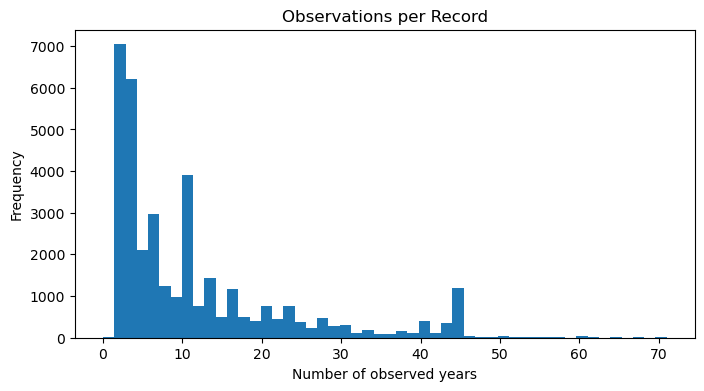

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(observations_per_record, bins=50)
plt.title("Observations per Record")
plt.xlabel("Number of observed years")
plt.ylabel("Frequency")
plt.show()

### 2.5 - SAVE INITIAL DATASET SNAPSHOT

Before performing any preprocessing, we save a clean snapshot of the dataset
exactly as it was loaded.

This provides:
- a reproducible checkpoint
- a rollback point if transformations introduce issues
- traceability across preprocessing steps

In [43]:
# Save checkpoint of the dataset after inspection
checkpoint_file = INTERIM_DIR / "lpd_master_initial.csv"

df.to_csv(checkpoint_file, index=False)

print(f"Initial dataset snapshot saved to: {checkpoint_file}")

Initial dataset snapshot saved to: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\lpd_master_initial.csv


In [44]:
checkpoint_file.exists()

True

---
# **3 - STANDARDIZE METADATA COLUMNS**

### 3.1 - CLEAN COLUMN NAMES

To ensure consistent data processing, we standardize all column names.

Cleaning operations include:
- converting to lowercase
- removing leading/trailing whitespace
- replacing spaces and punctuation with underscores
- collapsing multiple underscores
- ensuring machine-friendly naming

Example:

"Common Name" → "common_name"

In [45]:
import re

def clean_column_name(col):
    col = col.strip()
    col = col.lower()
    
    # replace spaces and punctuation with underscore
    col = re.sub(r"[^\w]+", "_", col)
    
    # remove duplicate underscores
    col = re.sub(r"_+", "_", col)
    
    # remove leading/trailing underscores
    col = col.strip("_")
    
    return col

In [46]:
# store original column names for reference
original_columns = df.columns.tolist()

# clean columns
df.columns = [clean_column_name(col) for col in df.columns]

print("Column names cleaned.")

Column names cleaned.


In [47]:
duplicate_cols = df.columns[df.columns.duplicated()]

print("Duplicate columns after cleaning:")
print(duplicate_cols)

Duplicate columns after cleaning:
Index([], dtype='object')


### 3.2 - STANDARDIZE CATEGORICAL FIELDS

After standardizing column names, we rebuild the main column groups so that all later
steps rely on clean, stable names.

Main goals:
- re-detect year columns
- rebuild metadata columns
- rebuild taxonomy, geography and monitoring groups
- store all groups in a reusable dictionary

This ensures that downstream preprocessing uses consistent column references.

In [48]:
# Re-detect year columns after column renaming
year_cols = [
    col for col in df.columns
    if str(col).isdigit() and 1900 <= int(col) <= 2100
]

year_cols = sorted(year_cols, key=lambda x: int(x))

print(f"Detected {len(year_cols)} year columns")
print("First 10 year columns:", year_cols[:10])
print("Last 10 year columns:", year_cols[-10:])

Detected 71 year columns
First 10 year columns: ['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959']
Last 10 year columns: ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']


In [49]:
metadata_cols = [col for col in df.columns if col not in year_cols]

print(f"Metadata columns: {len(metadata_cols)}")
print("First 20 metadata columns:")
print(metadata_cols[:20])

Metadata columns: 32
First 20 metadata columns:
['id', 'binomial', 'replicate', 'included_in_lpr2024', 'citation', 'class', 'order', 'family', 'genus', 'species', 'subspecies', 'common_name', 'location', 'country', 'all_countries', 'region', 'ipbes_region', 'ipbes_subregion', 'latitude', 'longitude']


In [50]:
def find_cols_by_keywords(columns, keywords):
    return [
        col for col in columns
        if any(keyword in col.lower() for keyword in keywords)
    ]

In [51]:
taxonomy_cols = find_cols_by_keywords(
    metadata_cols,
    ["class", "order", "family", "genus", "species", "binomial", "common"]
)

print(f"Taxonomy columns ({len(taxonomy_cols)}):")
print(taxonomy_cols)

Taxonomy columns (8):
['binomial', 'class', 'order', 'family', 'genus', 'species', 'subspecies', 'common_name']


In [52]:
geo_cols = find_cols_by_keywords(
    metadata_cols,
    ["country", "location", "latitude", "longitude", "lat", "long", "region", "continent"]
)

print(f"Geography columns ({len(geo_cols)}):")
print(geo_cols)

Geography columns (8):
['location', 'country', 'region', 'ipbes_region', 'ipbes_subregion', 'latitude', 'longitude', 'specific_location']


In [53]:
monitoring_cols = find_cols_by_keywords(
    metadata_cols,
    ["unit", "system", "method", "site", "source", "habitat", "biome", "realm", "replicate"]
)

print(f"Monitoring/context columns ({len(monitoring_cols)}):")
print(monitoring_cols)

Monitoring/context columns (9):
['replicate', 'system', 't_realm', 't_biome', 'fw_realm', 'fw_biome', 'm_realm', 'm_biome', 'units']


In [54]:
assigned_cols = set(id_cols + taxonomy_cols + geo_cols + monitoring_cols)
other_metadata_cols = [col for col in metadata_cols if col not in assigned_cols]

print(f"Other metadata columns ({len(other_metadata_cols)}):")
print(other_metadata_cols[:30])

Other metadata columns (7):
['id', 'included_in_lpr2024', 'citation', 'all_countries', 'm_ocean', 'native', 'unnamed_102']


In [55]:
group_summary = pd.DataFrame({
    "group": [
        "id_cols",
        "taxonomy_cols",
        "geo_cols",
        "monitoring_cols",
        "other_metadata_cols",
        "year_cols",
        "metadata_cols"
    ],
    "n_columns": [
        len(id_cols),
        len(taxonomy_cols),
        len(geo_cols),
        len(monitoring_cols),
        len(other_metadata_cols),
        len(year_cols),
        len(metadata_cols)
    ]
})

display(group_summary)

,group,n_columns
0,id_cols,1
1,taxonomy_cols,8
2,geo_cols,8
3,monitoring_cols,9
4,other_metadata_cols,7
5,year_cols,71
6,metadata_cols,32


In [56]:
column_groups = {
    "id_cols": id_cols,
    "taxonomy_cols": taxonomy_cols,
    "geo_cols": geo_cols,
    "monitoring_cols": monitoring_cols,
    "other_metadata_cols": other_metadata_cols,
    "year_cols": year_cols,
    "metadata_cols": metadata_cols
}

In [57]:
for group_name, cols in column_groups.items():
    print(f"\n{group_name} ({len(cols)} columns)")
    print(cols[:20] if len(cols) > 20 else cols)


id_cols (1 columns)
['ID']

taxonomy_cols (8 columns)
['binomial', 'class', 'order', 'family', 'genus', 'species', 'subspecies', 'common_name']

geo_cols (8 columns)
['location', 'country', 'region', 'ipbes_region', 'ipbes_subregion', 'latitude', 'longitude', 'specific_location']

monitoring_cols (9 columns)
['replicate', 'system', 't_realm', 't_biome', 'fw_realm', 'fw_biome', 'm_realm', 'm_biome', 'units']

other_metadata_cols (7 columns)
['id', 'included_in_lpr2024', 'citation', 'all_countries', 'm_ocean', 'native', 'unnamed_102']

year_cols (71 columns)
['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969']

metadata_cols (32 columns)
['id', 'binomial', 'replicate', 'included_in_lpr2024', 'citation', 'class', 'order', 'family', 'genus', 'species', 'subspecies', 'common_name', 'location', 'country', 'all_countries', 'region', 'ipbes_region', 'ipbes_subregion', 'latitude', 'longi

In [58]:
import json

CONFIG_DIR = PROJECT_ROOT / "config"
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

column_groups_file = CONFIG_DIR / "column_groups.json"

with open(column_groups_file, "w") as f:
    json.dump(column_groups, f, indent=4)

print(f"Column groups saved to: {column_groups_file}")

Column groups saved to: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\config\column_groups.json


In [59]:
with open(column_groups_file, "r") as f:
    column_groups = json.load(f)

### 3.3 - VALIDATE GEOGRAPHIC INFORMATION

Categorical metadata fields often contain inconsistencies such as:

- leading/trailing whitespace
- inconsistent capitalization
- placeholder strings representing missing values
- formatting inconsistencies

In this section we standardize categorical text fields by:

- trimming whitespace
- converting placeholder values to proper NaN
- normalizing casing
- ensuring consistent string formatting

This improves filtering, grouping and downstream modeling reliability.

In [60]:
# Detect categorical (object) columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Detected {len(categorical_cols)} categorical columns")
print(categorical_cols[:20])

Detected 24 categorical columns
['binomial', 'citation', 'class', 'order', 'family', 'genus', 'species', 'subspecies', 'common_name', 'location', 'country', 'all_countries', 'region', 'ipbes_region', 'ipbes_subregion', 'system', 't_realm', 't_biome', 'fw_realm', 'fw_biome']


In [61]:
# Common placeholder values for missing data
missing_placeholders = [
    "na", "n/a", "nan", "null", "none",
    "unknown", "not available", "missing", ""
]

In [62]:
def clean_categorical_value(value):
    
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    if value.lower() in missing_placeholders:
        return np.nan
    
    return value

In [63]:
for col in categorical_cols:
    df[col] = df[col].apply(clean_categorical_value)

print("Categorical fields cleaned.")

Categorical fields cleaned.


In [64]:
lowercase_cols = ["system", "units", "country"]

for col in lowercase_cols:
    if col in df.columns:
        df[col] = df[col].str.lower()

print("Selected categorical columns converted to lowercase.")

Selected categorical columns converted to lowercase.


In [65]:
if "system" in df.columns:
    print("System categories:")
    display(df["system"].value_counts())

System categories:


system
marine         16258
terrestrial    11858
freshwater      7880
Name: count, dtype: int64

In [66]:
if "units" in df.columns:
    print("Units categories:")
    display(df["units"].value_counts().head(20))

Units categories:


units
sample: abundance (counts)                                   9066
number of individuals                                        2873
average number of individuals                                1986
individuals                                                  1471
annual index                                                 1238
catch per tow                                                 957
cpue (number of individuals observed/number of transects)     670
annual index of population change                             649
number of breeding pairs                                      519
cpue (weight/ (minute towed*tow length))                      443
index                                                         408
sample: density (counts/fixed areas)                          371
number of nests                                               282
estimated number of individuals                               268
biomass (kg)                                                  267
bree

In [67]:
if "country" in df.columns:
    print("Top countries:")
    display(df["country"].value_counts().head(20))

Top countries:


country
australia                       11413
canada                           6297
brazil                           3693
united states                    2066
spain                             870
united kingdom                    665
norway                            593
south africa                      568
france                            470
germany                           320
india                             309
namibia                           298
italy                             292
belize                            285
bahamas                           282
mexico                            280
sweden                            262
russian federation                254
tanzania, united republic of      212
finland                           212
Name: count, dtype: int64

In [68]:
if "country" in df.columns:
    print("Top countries:")
    display(df["country"].value_counts().head(20))

Top countries:


country
australia                       11413
canada                           6297
brazil                           3693
united states                    2066
spain                             870
united kingdom                    665
norway                            593
south africa                      568
france                            470
germany                           320
india                             309
namibia                           298
italy                             292
belize                            285
bahamas                           282
mexico                            280
sweden                            262
russian federation                254
tanzania, united republic of      212
finland                           212
Name: count, dtype: int64

### 3.4 - VALIDATE TAXONOMIC METADATA

Taxonomic metadata provides biological context for each population record.

In this section we inspect:

- taxonomic hierarchy completeness
- number of unique species
- distribution across classes
- potential inconsistencies

This helps assess biodiversity coverage and identify potential taxonomic imbalances.

In [69]:
print("Taxonomy columns detected:")
print(taxonomy_cols)

Taxonomy columns detected:
['binomial', 'class', 'order', 'family', 'genus', 'species', 'subspecies', 'common_name']


In [70]:
if "binomial" in df.columns:
    print("Unique species:", df["binomial"].nunique())

Unique species: 5177


In [71]:
if "class" in df.columns:
    class_counts = df["class"].value_counts()
    display(class_counts)

class
Aves              17834
Actinopteri       10081
Mammalia           5910
Reptilia            828
Amphibia            699
Elasmobranchii      591
Myxini               28
Holocephali          12
Petromyzonti          9
Dipneusti             3
Coelacanthi           1
Name: count, dtype: int64

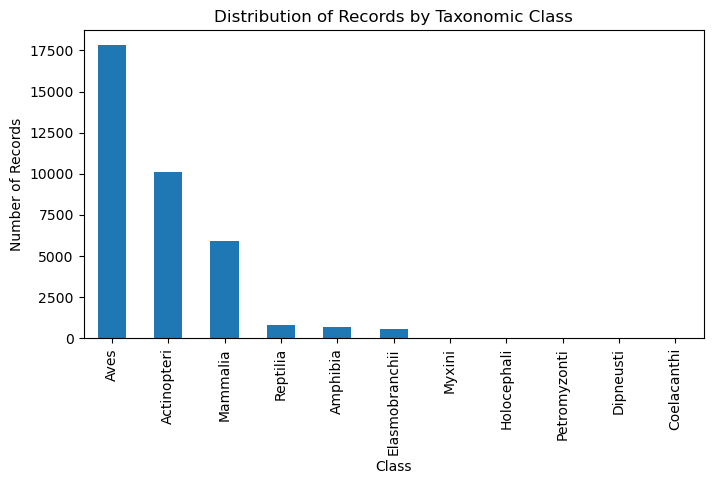

In [72]:
import matplotlib.pyplot as plt

if "class" in df.columns:
    
    plt.figure(figsize=(8,4))
    df["class"].value_counts().plot(kind="bar")
    
    plt.title("Distribution of Records by Taxonomic Class")
    plt.xlabel("Class")
    plt.ylabel("Number of Records")
    
    plt.show()

In [73]:
taxonomy_missing = df[taxonomy_cols].isna().sum().sort_values(ascending=False)

taxonomy_missing_df = pd.DataFrame({
    "missing_count": taxonomy_missing,
    "missing_pct": taxonomy_missing / len(df) * 100
})

display(taxonomy_missing_df)

,missing_count,missing_pct
subspecies,33232,92.321369
binomial,0,0.000000
order,0,0.000000
class,0,0.000000
family,0,0.000000
genus,0,0.000000
species,0,0.000000
common_name,0,0.000000


In [74]:
if "binomial" in df.columns:

    species_replicates = df["binomial"].value_counts()

    print("Average populations per species:")
    print(species_replicates.mean())

    display(species_replicates.head(10))

Average populations per species:
6.953061618698087


binomial
Calidris_ruficollis          1083
Tringa_nebularia              879
Limosa_lapponica              829
Calidris_acuminata            777
Calidris_ferruginea           759
Numenius_madagascariensis     696
Calidris_tenuirostris         451
Charadrius_mongolus           420
Calidris_canutus              416
Xenus_cinereus                362
Name: count, dtype: int64

---
# **4 - TIME-SERIES STRUCTURE PREPARATION**

### 4.1 - IDENTIFY YEAR COLUMNS

The year columns represent the population time series for each monitored population.

Before performing time-series analysis we verify:

- the detected year coverage
- that the year columns correspond to valid calendar years
- the current data types of the year columns

This ensures that the dataset contains a consistent temporal structure.

In [75]:
print(f"Number of detected year columns: {len(year_cols)}")

print("First year:", year_cols[0])
print("Last year:", year_cols[-1])

Number of detected year columns: 71
First year: 1950
Last year: 2020


In [76]:
detected_years = list(map(int, year_cols))
expected_years = list(range(min(detected_years), max(detected_years) + 1))

missing_years = sorted(set(expected_years) - set(detected_years))

print("Missing years in sequence:", missing_years if missing_years else "None")

Missing years in sequence: None


In [77]:
df[year_cols].dtypes.value_counts()

float64    71
Name: count, dtype: int64

### 4.2 - CONVERT YEAR COLUMNS TO NUMERIC

Population values must be numeric to support time-series analysis.

We convert all year columns to numeric values using a safe conversion:

- non-numeric values are coerced to NaN
- existing numeric values are preserved

In [78]:
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")

print("Year columns converted to numeric.")

Year columns converted to numeric.


In [79]:
df[year_cols].dtypes.value_counts()

float64    71
Name: count, dtype: int64

### 4.3 - CREATE LONG FORMAT DATASET

The original dataset stores population observations in wide format, with one column per year.

For time-series analysis, plotting and feature engineering, it is more useful to reshape the dataset into long format, where each row represents a single observed population value for a given year.

Target structure:

- one row per population-year observation
- metadata columns retained
- `year` column added
- `population` column added

This format will support:
- plotting population trajectories
- computing observation counts
- detecting gaps and continuity
- building time-series quality metrics

In [80]:
# Reshape from wide format (one column per year)
# to long format (one row per record-year observation)

df_long = df.melt(
    id_vars=metadata_cols,
    value_vars=year_cols,
    var_name="year",
    value_name="population"
)

print("Wide-to-long transformation completed.")
print("Long dataset shape (including missing population rows):", df_long.shape)

Wide-to-long transformation completed.
Long dataset shape (including missing population rows): (2555716, 34)


In [81]:
df_long["year"] = df_long["year"].astype(int)

print("Year column converted to integer.")

Year column converted to integer.


In [82]:
df_long = df_long.dropna(subset=["population"]).copy()

print("Rows with missing population values removed.")
print("Long dataset shape (observed population rows only):", df_long.shape)

Rows with missing population values removed.
Long dataset shape (observed population rows only): (420356, 34)


In [83]:
display(df_long.head())

,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,year,population
81,82,Equus_zebra,0,1,"Duncan, P. e. (1992). ""Zebras, Asses and Horses. An action plan of the conservation of wild equids."" IUCN/SSC Equid ...",Mammalia,Perissodactyla,Equidae,Equus,zebra,hartmannae,Cape mountain zebra,Namibia,namibia,Namibia,Africa,Africa,Southern Africa,-22.000000,17.000000,0,terrestrial,Afrotropical,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,individuals,1,NaN,1950,50000.0
82,83,Equus_zebra,1,0,"IUCN/SSC Equid Specialist Group (2002). Equids: Zebras, Asses and Horses. Status survey and conservation action plan...",Mammalia,Perissodactyla,Equidae,Equus,zebra,zebra,Cape mountain zebra,"South Africa, Total metapopulation",south africa,South Africa,Africa,Africa,Southern Africa,-30.000000,26.000000,0,terrestrial,Afrotropical,"Mediterranean forests, woodlands and scrub",NaN,NaN,NaN,NaN,NaN,number of individuals,1,NaN,1950,80.0
88,89,Giraffa_camelopardalis,1,0,"East, R. (1998). African Antelope database. Occasional paper of the IUCN Species Survival Commision No. 21. I. S. A....",Mammalia,Artiodactyla,Giraffidae,Giraffa,camelopardalis,thornicrofti,Giraffe,Luangwa Valley,zambia,Zambia,Africa,Africa,Southern Africa,-13.000000,31.500000,1,terrestrial,Afrotropical,"Tropical and subtropical grasslands, savannas and shrublands",NaN,NaN,NaN,NaN,NaN,individuals,1,NaN,1950,250.0
252,253,Amazona_versicolor,0,1,"Juniper, T. and M. Parr (1998). Parrots: A guide to the parrots of the world. Haarlem, Netherlands, Ger Meesters Boe...",Aves,Psittaciformes,Psittacidae,Amazona,versicolor,NaN,St Lucia amazon,St Lucia,saint lucia,Saint Lucia,Latin America and Caribbean,Americas,Caribbean,13.905000,-60.970280,1,terrestrial,Neotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,number of individuals,1,NaN,1950,1000.0
268,269,Alauda_arvensis,0,1,NERC Centre for Population Biology (1999). The Global Populations Dynamics Database. http://cpbnts1.bio.ic.ac.uk/gpd...,Aves,Passeriformes,Alaudidae,Alauda,arvensis,NaN,Eurasian skylark,Skokholm Island,united kingdom,United Kingdom,Europe,Europe and Central Asia,Central and Western Europe,51.698949,-5.277271,1,terrestrial,Palearctic,"Temperate grasslands, savannas and shrublands",NaN,NaN,NaN,NaN,NaN,number of breeding pairs,1,NaN,1950,9.0


In [84]:
print("Year range in long dataset:", df_long["year"].min(), "-", df_long["year"].max())
print("Total observed population values:", len(df_long))

Year range in long dataset: 1950 - 2020
Total observed population values: 420356


In [85]:
print("Columns in long dataset:")
print(df_long.columns.tolist())

Columns in long dataset:
['id', 'binomial', 'replicate', 'included_in_lpr2024', 'citation', 'class', 'order', 'family', 'genus', 'species', 'subspecies', 'common_name', 'location', 'country', 'all_countries', 'region', 'ipbes_region', 'ipbes_subregion', 'latitude', 'longitude', 'specific_location', 'system', 't_realm', 't_biome', 'fw_realm', 'fw_biome', 'm_realm', 'm_ocean', 'm_biome', 'units', 'native', 'unnamed_102', 'year', 'population']


In [86]:
if "id" in df_long.columns:
    print("Unique population records in long dataset:", df_long["id"].nunique())

Unique population records in long dataset: 35980


### 4.4 - VALIDATE TIME-SERIES INTEGRITY

Before computing time-series quality metrics, we perform a final integrity check on the long-format population data.

The objective is to identify potential anomalies such as:

- negative population values
- extreme values
- impossible or suspicious patterns

These checks help ensure that the time-series data is structurally valid before downstream analysis.

In [87]:
negative_count = (df_long["population"] < 0).sum()

print(f"Negative population observations: {negative_count}")

Negative population observations: 0


In [88]:
if negative_count > 0:
    display(df_long[df_long["population"] < 0].head())

In [89]:
min_population = df_long["population"].min()
max_population = df_long["population"].max()

print(f"Minimum population value: {min_population}")
print(f"Maximum population value: {max_population}")

Minimum population value: 0.0
Maximum population value: 2500000000000000.0


In [90]:
display(df_long[df_long["population"] == max_population].head())

,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,year,population
1417,1467,Lutjanus_campechanus,0,1,RAM Legacy Stock Assessment Database (2021) ‘RAM Legacy Stock Assessment Database v4.495’. Zenodo. Available at: htt...,Actinopteri,Perciformes,Lutjanidae,Lutjanus,campechanus,NaN,Northern red snapper,US waters of Gulf of Mexico,united states,United States,North America,Americas,North America,28.0,-90.42,0,marine,NaN,NaN,NaN,NaN,Atlantic tropical and subtropical,Caribbean Sea and Gulf of Mexico,NaN,spawning stock biomass (thousand billion eggs),1,NaN,1950,2.500000e+15


In [91]:
display(df_long[df_long["population"] == min_population].head())

,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,year,population
1563,1613,Branta_leucopsis,1,0,"Madsen, J., G. Cracknell, et al., Eds. (1999). Goose Populations of the Western Palaearctic. A Review of the Status ...",Aves,Anseriformes,Anatidae,Branta,leucopsis,NaN,Barnacle goose,"Baltic (Sweden, Estonia)",sweden,Sweden,Europe,Europe and Central Asia,Central and Western Europe,59.610560,18.750280,0,terrestrial,Palearctic,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,breeding pairs (from graphic),1,NaN,1950,0.0
1635,1685,Haematopus_ostralegus,1,0,"Väisänen, R. A., E. Lammi, et al. (1998). Miuuttuva Pesimälinnusto. Helsinki, Otava 1890.",Aves,Charadriiformes,Haematopodidae,Haematopus,ostralegus,NaN,Eurasian oystercatcher,SÃ¶derskÃ¤r,finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,59.933330,24.450000,1,marine,NaN,NaN,NaN,NaN,Atlantic north temperate,North Sea and Baltic Sea,NaN,breeding pairs (from graphic),1,NaN,1950,0.0
1674,1725,Larus_ridibundus,0,1,"Hälterlein, B., P. Südbeck, et al. (2000). ""Brutbestandsentwicklung der Küstenvögel an Nord- und Ostsee unter besond...",Aves,Charadriiformes,Laridae,Larus,ridibundus,NaN,Black-headed gull,German North Sea coast,germany,Germany,Europe,Europe and Central Asia,Central and Western Europe,53.864440,8.606390,0,marine,NaN,NaN,NaN,NaN,Atlantic north temperate,North Sea and Baltic Sea,NaN,breeding pairs (from graphic),1,NaN,1950,0.0
1766,1819,Rissa_tridactyla,0,1,"Garthe, S., B.-O. Flore, et al. (2000). ""Brutbestandsentwicklung der Möwen (Laridae) an der deutschen Nordseeküste i...",Aves,Charadriiformes,Laridae,Rissa,tridactyla,NaN,Black-legged kittiwake,Helgoland,germany,Germany,Europe,Europe and Central Asia,Central and Western Europe,54.166670,7.883330,0,marine,NaN,NaN,NaN,NaN,Atlantic north temperate,North Sea and Baltic Sea,NaN,breeding pairs,1,NaN,1950,0.0
5450,5991,Columba_oenas,0,1,"Williamson, M. (1983). ""The Land-Bird Community of Skokholm: Ordination and Turnover."" Oikos 41(3): 378-384.| NERC C...",Aves,Columbiformes,Columbidae,Columba,oenas,NaN,Stock dove,Skokholm Island,united kingdom,United Kingdom,Europe,Europe and Central Asia,Central and Western Europe,51.698949,-5.277271,1,terrestrial,Palearctic,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,pairs,1,NaN,1950,0.0


In [92]:
zero_count = (df_long["population"] == 0).sum()
zero_share = zero_count / len(df_long)

print(f"Zero population observations: {zero_count}")
print(f"Zero share of observed population values: {zero_share:.2%}")

Zero population observations: 62002
Zero share of observed population values: 14.75%


In [93]:
display(df_long["population"].describe())

count    4.203560e+05
mean     1.169547e+11
std      1.307734e+13
min      0.000000e+00
25%      2.490000e-01
50%      5.000000e+00
75%      1.000000e+02
max      2.500000e+15
Name: population, dtype: float64

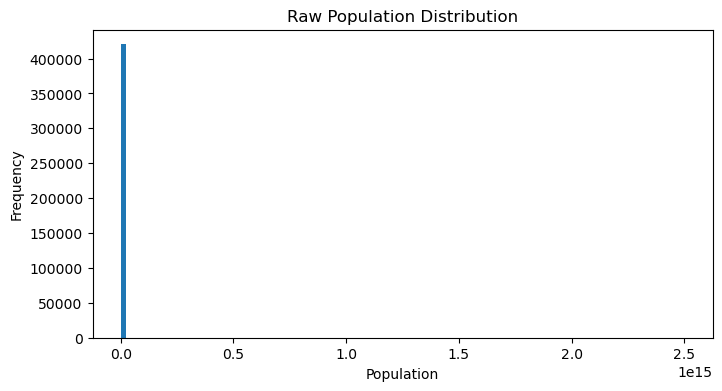

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_long["population"], bins=100)
plt.title("Raw Population Distribution")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

The raw population distribution is extremely skewed due to the presence of a small number of very large population estimates. Most observations fall into relatively small population ranges, causing the histogram to collapse near zero when plotted on the original scale. This confirms the need for log transformation or relative-change modeling when building predictive models.

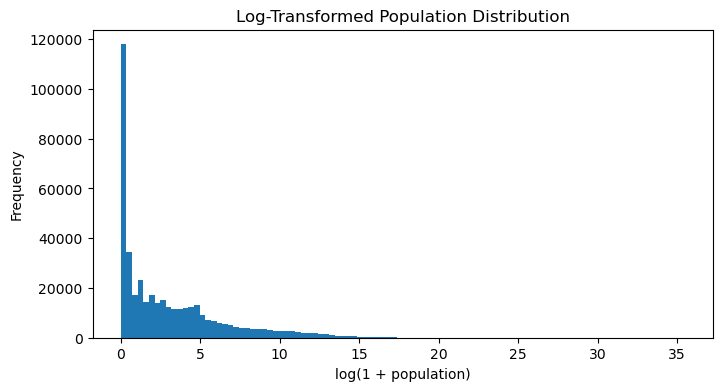

In [95]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df_long["population"]), bins=100)
plt.title("Log-Transformed Population Distribution")
plt.xlabel("log(1 + population)")
plt.ylabel("Frequency")
plt.show()

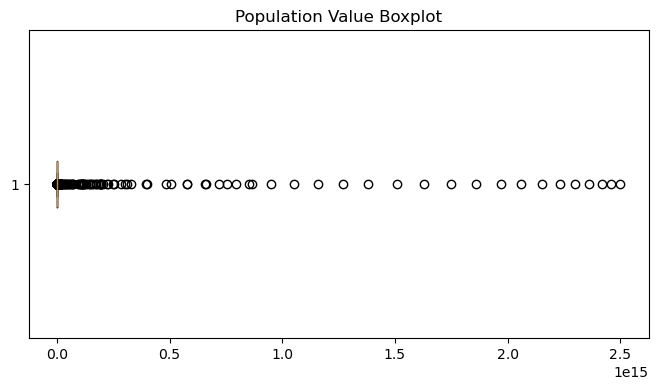

In [96]:
plt.figure(figsize=(8,4))
plt.boxplot(df_long["population"], vert=False)
plt.title("Population Value Boxplot")
plt.show()

In [97]:
non_finite_count = (~np.isfinite(df_long["population"])).sum()

print(f"Non-finite population values: {non_finite_count}")

Non-finite population values: 0


In [98]:
if non_finite_count > 0:
    display(df_long[~np.isfinite(df_long["population"])].head())

In [99]:
if "id" in df_long.columns:
    duplicated_record_year = df_long.duplicated(subset=["id", "year"]).sum()
    print(f"Duplicated record-year observations: {duplicated_record_year}")

Duplicated record-year observations: 0


In [100]:
if "id" in df_long.columns and duplicated_record_year > 0:
    display(df_long[df_long.duplicated(subset=["id", "year"], keep=False)].head())

In [101]:
if "units" in df_long.columns:
    unit_counts = df_long["units"].value_counts()
    display(unit_counts.head(20))

units
sample: abundance (counts)                  82887
annual index                                52419
annual index of population change           28849
average number of individuals               20699
number of individuals                       20688
individuals                                 13595
catch per tow                               13132
index                                       10597
ssb-mt                                      10338
number of breeding pairs                     6097
sample: density (counts/fixed areas)         3927
biomass (kg)                                 3540
number of nests                              3441
population index                             3392
index values                                 2836
population estimate (individuals)            2668
proxy: breeding pairs                        2569
pairs                                        2379
cpue (weight/ (minute towed*tow length))     2274
population estimate                         

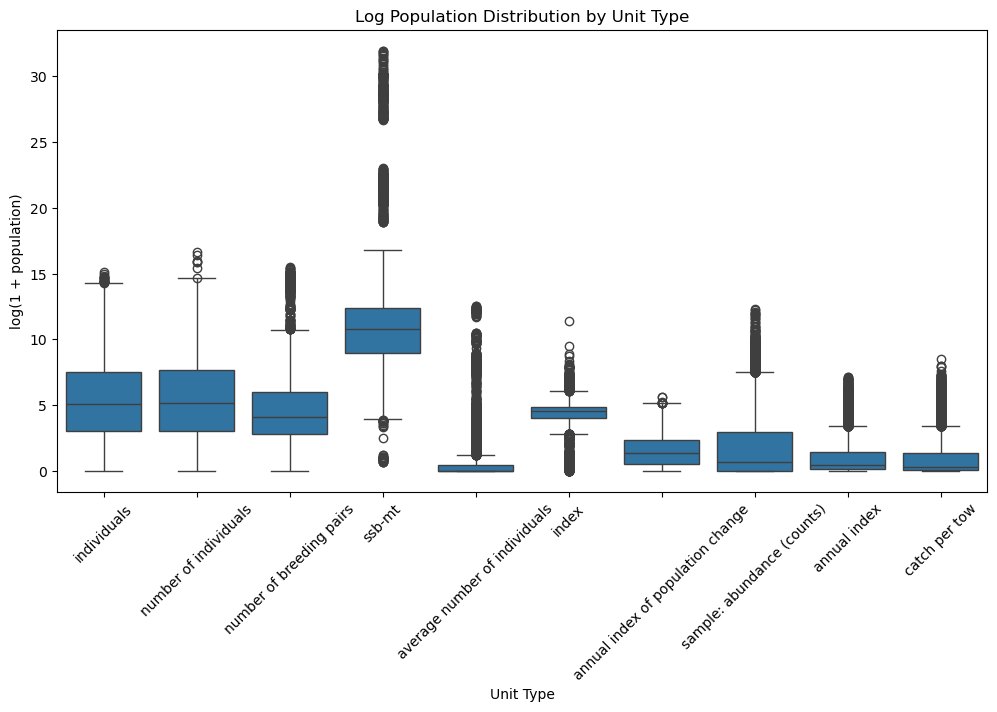

In [102]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,6))

# limit to most common units to keep plot readable
top_units = df_long["units"].value_counts().head(10).index
subset = df_long[df_long["units"].isin(top_units)]

sns.boxplot(
    data=subset,
    x="units",
    y=np.log1p(subset["population"])
)

plt.title("Log Population Distribution by Unit Type")
plt.xlabel("Unit Type")
plt.ylabel("log(1 + population)")

plt.xticks(rotation=45)
plt.show()

In [103]:
df_long.nlargest(20, "population")[["binomial", "units", "population", "country"]]

,binomial,units,population,country
1417,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.500000e+15,united states
37413,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.460000e+15,united states
73409,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.420000e+15,united states
109405,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.360000e+15,united states
145401,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.300000e+15,united states
181397,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.230000e+15,united states
217393,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.150000e+15,united states
253389,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),2.060000e+15,united states
289385,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),1.970000e+15,united states
325381,Lutjanus_campechanus,spawning stock biomass (thousand billion eggs),1.860000e+15,united states


---
# **5 - BUILD TIME-SERIES QUALITY METRICS**

To evaluate the suitability of each population record for forecasting and analysis,
we compute a set of time-series quality metrics.

These metrics summarize the structure of each population time series and will later
support filtering rules for dataset generation.

Key metrics include:

- number of observations
- first observation year
- last observation year
- time span
- gap statistics
- continuity ratio
- zero-value statistics

The resulting table will contain one row per population record and will serve
as the central reference for dataset filtering.

### 5.1 - OBSERVATION COUNT

The first time-series quality metric we compute is the number of observations
available for each monitored population.

Each record in the dataset represents a monitored population, but observations
are not available every year.

The observation count measures how many years of population data exist for
each population record.

This metric is important because:

- forecasting models require sufficient historical data
- very short time series are unlikely to produce reliable predictions

We compute this metric using the long-format dataset (`df_long`).

In [104]:
obs_count = (
    df_long
    .groupby("id")
    .agg(n_obs=("year", "count"))
    .reset_index()
)

display(obs_count.head())

,id,n_obs
0,1,3
1,2,3
2,3,6
3,4,14
4,5,25


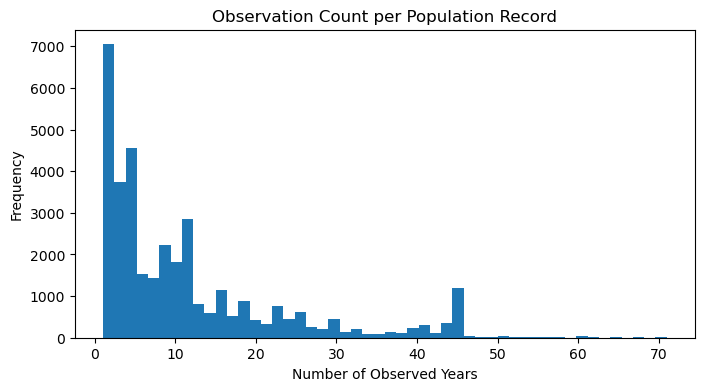

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(obs_count["n_obs"], bins=50)

plt.title("Observation Count per Population Record")
plt.xlabel("Number of Observed Years")
plt.ylabel("Frequency")

plt.show()

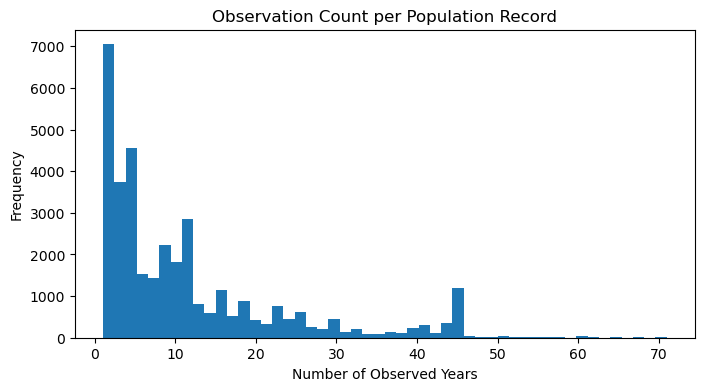

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(obs_count["n_obs"], bins=50)

plt.title("Observation Count per Population Record")
plt.xlabel("Number of Observed Years")
plt.ylabel("Frequency")

plt.show()

In [107]:
display(obs_count["n_obs"].describe())

count    35980.000000
mean        11.683046
std         12.021634
min          1.000000
25%          3.000000
50%          7.000000
75%         15.000000
max         71.000000
Name: n_obs, dtype: float64

In [108]:
print("Records with ≥10 observations:", (obs_count["n_obs"] >= 10).sum())
print("Records with ≥15 observations:", (obs_count["n_obs"] >= 15).sum())
print("Records with ≥20 observations:", (obs_count["n_obs"] >= 20).sum())

Records with ≥10 observations: 15430
Records with ≥15 observations: 9335
Records with ≥20 observations: 6779


In [109]:
population_metrics = obs_count.copy()

### 5.2 - TEMPORAL SPAN

Observation count tells us how many years of data exist for each population record,
but it does not tell us how far apart those observations are.

To understand the temporal extent of each time series, we compute:

- first observation year
- last observation year
- time span

The time span is defined as:

time_span = last_obs_year - first_obs_year + 1

This metric is important because two records may have the same number of observations
but very different temporal structures.

In [110]:
temporal_span = (
    df_long
    .groupby("id")
    .agg(
        first_obs_year=("year", "min"),
        last_obs_year=("year", "max")
    )
    .reset_index()
)

display(temporal_span.head())

,id,first_obs_year,last_obs_year
0,1,1985,2002
1,2,1958,1987
2,3,1977,1990
3,4,1976,1990
4,5,1973,1997


In [111]:
temporal_span["time_span"] = (
    temporal_span["last_obs_year"]
    - temporal_span["first_obs_year"]
    + 1
)

display(temporal_span.head())

,id,first_obs_year,last_obs_year,time_span
0,1,1985,2002,18
1,2,1958,1987,30
2,3,1977,1990,14
3,4,1976,1990,15
4,5,1973,1997,25


In [112]:
population_metrics = population_metrics.merge(
    temporal_span,
    on="id",
    how="left"
)

display(population_metrics.head())

,id,n_obs,first_obs_year,last_obs_year,time_span
0,1,3,1985,2002,18
1,2,3,1958,1987,30
2,3,6,1977,1990,14
3,4,14,1976,1990,15
4,5,25,1973,1997,25


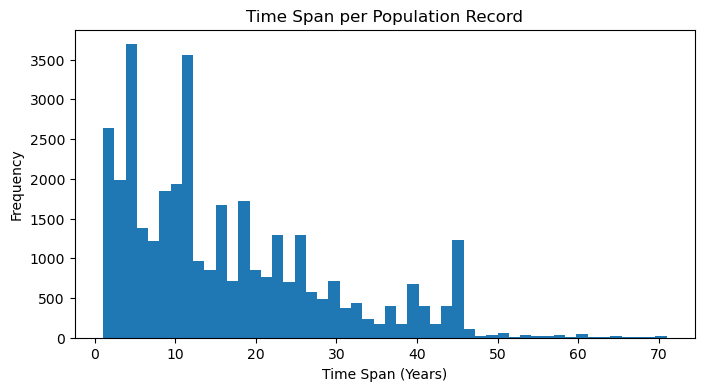

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(population_metrics["time_span"], bins=50)

plt.title("Time Span per Population Record")
plt.xlabel("Time Span (Years)")
plt.ylabel("Frequency")

plt.show()

In [114]:
display(population_metrics["time_span"].describe())

count    35980.000000
mean        16.259033
std         12.650655
min          1.000000
25%          6.000000
50%         12.000000
75%         23.000000
max         71.000000
Name: time_span, dtype: float64

In [115]:
display(
    population_metrics[["n_obs", "time_span"]].describe()
)

,n_obs,time_span
count,35980.000000,35980.000000
mean,11.683046,16.259033
std,12.021634,12.650655
min,1.000000,1.000000
25%,3.000000,6.000000
50%,7.000000,12.000000
75%,15.000000,23.000000
max,71.000000,71.000000


In [116]:
display(
    population_metrics
    .sort_values("time_span", ascending=False)
    .head(10)
)

,id,n_obs,first_obs_year,last_obs_year,time_span
35977,1000005,18,1950,2020,71
15432,19338,71,1950,2020,71
35924,800000,71,1950,2020,71
15394,19300,71,1950,2020,71
15372,19278,71,1950,2020,71
15391,19297,71,1950,2020,71
1365,1415,71,1950,2020,71
1986,2041,71,1950,2020,71
15338,19244,71,1950,2020,71
15351,19257,71,1950,2020,71


### 5.3 - GAP METRICS

Observation count and temporal span describe how much data exists for each
population record, but they do not reveal whether observations occur
consecutively.

In this section we compute metrics describing gaps in the time series.

Definitions:

- gap: missing years between two observed years
- n_gaps: number of gaps within a time series
- max_gap: largest gap between consecutive observations

These metrics help determine whether a population time series is suitable
for forecasting.

In [117]:
import numpy as np
import pandas as pd

def compute_gap_metrics(group):

    years = np.sort(group["year"].values)

    if len(years) <= 1:
        return pd.Series({
            "n_gaps": 0,
            "max_gap": 0
        })

    year_diffs = np.diff(years)

    gaps = year_diffs - 1
    gaps[gaps < 0] = 0

    return pd.Series({
        "n_gaps": (gaps > 0).sum(),
        "max_gap": gaps.max()
    })


gap_metrics = (
    df_long
    .groupby("id")
    .apply(compute_gap_metrics)
    .reset_index()
)

display(gap_metrics.head())

C:\Users\Vaccari\AppData\Local\Temp\ipykernel_27660\2862002012.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_gap_metrics)


,id,n_gaps,max_gap
0,1,2,9
1,2,2,16
2,3,3,5
3,4,1,1
4,5,0,0


In [118]:
population_metrics = population_metrics.merge(
    gap_metrics,
    on="id",
    how="left"
)

print("Columns after merge:")
print(population_metrics.columns)

display(population_metrics.head())

Columns after merge:
Index(['id', 'n_obs', 'first_obs_year', 'last_obs_year', 'time_span', 'n_gaps',
       'max_gap'],
      dtype='object')


,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap
0,1,3,1985,2002,18,2,9
1,2,3,1958,1987,30,2,16
2,3,6,1977,1990,14,3,5
3,4,14,1976,1990,15,1,1
4,5,25,1973,1997,25,0,0


In [119]:
population_metrics["continuity_ratio"] = (
    population_metrics["n_obs"] /
    population_metrics["time_span"]
)

display(population_metrics.head())

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio
0,1,3,1985,2002,18,2,9,0.166667
1,2,3,1958,1987,30,2,16,0.100000
2,3,6,1977,1990,14,3,5,0.428571
3,4,14,1976,1990,15,1,1,0.933333
4,5,25,1973,1997,25,0,0,1.000000


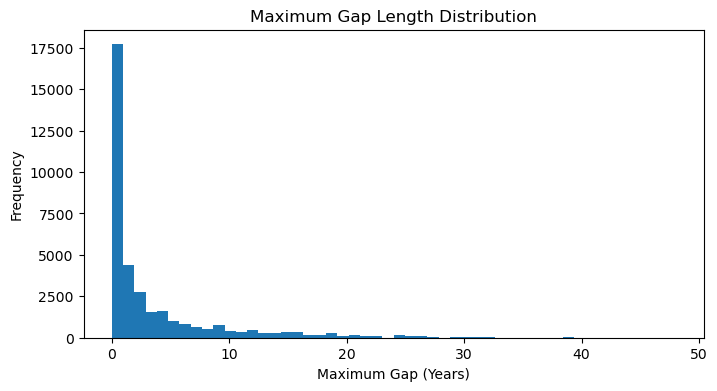

In [120]:
plt.figure(figsize=(8,4))
plt.hist(population_metrics["max_gap"], bins=50)

plt.title("Maximum Gap Length Distribution")
plt.xlabel("Maximum Gap (Years)")
plt.ylabel("Frequency")

plt.show()

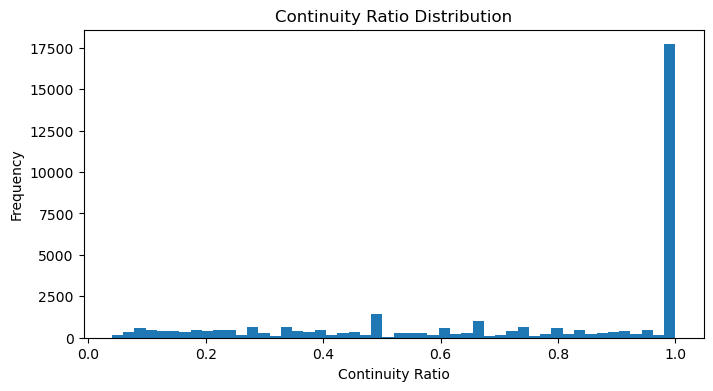

In [121]:
plt.figure(figsize=(8,4))
plt.hist(population_metrics["continuity_ratio"], bins=50)

plt.title("Continuity Ratio Distribution")
plt.xlabel("Continuity Ratio")
plt.ylabel("Frequency")

plt.show()

In [122]:
display(
    population_metrics[
        ["n_gaps", "max_gap", "continuity_ratio"]
    ].describe()
)

,n_gaps,max_gap,continuity_ratio
count,35980.000000,35980.000000,35980.000000
mean,1.109978,3.301723,0.745107
std,1.661223,5.899325,0.314243
min,0.000000,0.000000,0.040000
25%,0.000000,0.000000,0.500000
50%,1.000000,1.000000,0.958333
75%,2.000000,4.000000,1.000000
max,30.000000,48.000000,1.000000


### 5.4 - ZERO VALUE ANALYSIS

Population values equal to zero require careful interpretation.

A zero population value may represent:

- true local extinction
- non-detection during monitoring
- a temporary population collapse
- a recording artifact

Rather than removing zero values, we compute statistics describing their
frequency within each population time series.

Metrics computed:

- zero_count: number of observations equal to zero
- zero_share: proportion of observations that are zero

In [123]:
df_long["is_zero"] = df_long["population"] == 0

In [124]:
zero_metrics = (
    df_long
    .groupby("id")
    .agg(
        zero_count=("is_zero", "sum")
    )
    .reset_index()
)

display(zero_metrics.head())

,id,zero_count
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [125]:
population_metrics = population_metrics.merge(
    zero_metrics,
    on="id",
    how="left"
)

display(population_metrics.head())

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count
0,1,3,1985,2002,18,2,9,0.166667,0
1,2,3,1958,1987,30,2,16,0.100000,0
2,3,6,1977,1990,14,3,5,0.428571,0
3,4,14,1976,1990,15,1,1,0.933333,0
4,5,25,1973,1997,25,0,0,1.000000,0


In [126]:
population_metrics["zero_share"] = (
    population_metrics["zero_count"] /
    population_metrics["n_obs"]
)

display(population_metrics.head())

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share
0,1,3,1985,2002,18,2,9,0.166667,0,0.0
1,2,3,1958,1987,30,2,16,0.100000,0,0.0
2,3,6,1977,1990,14,3,5,0.428571,0,0.0
3,4,14,1976,1990,15,1,1,0.933333,0,0.0
4,5,25,1973,1997,25,0,0,1.000000,0,0.0


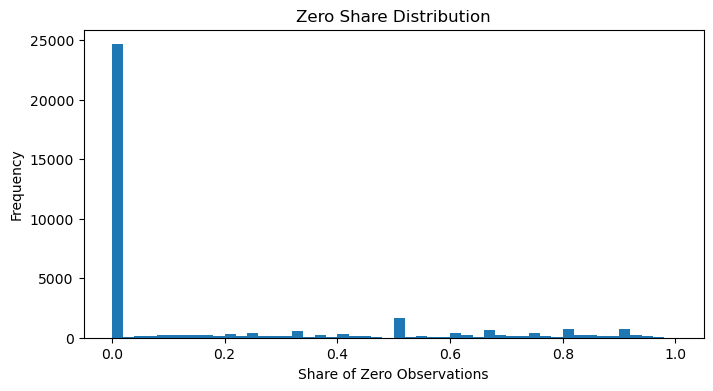

In [127]:
plt.figure(figsize=(8,4))
plt.hist(population_metrics["zero_share"], bins=50)

plt.title("Zero Share Distribution")
plt.xlabel("Share of Zero Observations")
plt.ylabel("Frequency")

plt.show()

In [128]:
display(
    population_metrics[
        ["zero_count", "zero_share"]
    ].describe()
)

,zero_count,zero_share
count,35980.000000,35980.000000
mean,1.723235,0.166797
std,3.969316,0.287652
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.250000
max,49.000000,1.000000


*How to interpret the zero share:*

- 0 - 0.05 = Likely stable populations with occasional detection issues.
- 0 - 0.05 = Possible population collapses or intermittent detection.
- \> 0.5 = Likely problematic series or persistent absence.

### 5.5 - RECENCY METRICS

For forecasting tasks, it is important that population time series include
recent observations.

A population record with many observations may still be unsuitable for
prediction if monitoring stopped several decades ago.

To assess recency, we compute:

- last observation year
- years since last observation

These metrics help identify time series that are still relevant for
current ecological conditions.

In [129]:
display(population_metrics["last_obs_year"].describe())

count    35980.000000
mean      2008.066037
std         10.166229
min       1964.000000
25%       2001.000000
50%       2010.000000
75%       2016.000000
max       2020.000000
Name: last_obs_year, dtype: float64

In [130]:
DATASET_LAST_YEAR = 2020

population_metrics["years_since_last_obs"] = (
    DATASET_LAST_YEAR -
    population_metrics["last_obs_year"]
)

display(population_metrics.head())

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs
0,1,3,1985,2002,18,2,9,0.166667,0,0.0,18
1,2,3,1958,1987,30,2,16,0.100000,0,0.0,33
2,3,6,1977,1990,14,3,5,0.428571,0,0.0,30
3,4,14,1976,1990,15,1,1,0.933333,0,0.0,30
4,5,25,1973,1997,25,0,0,1.000000,0,0.0,23


In [131]:
DATASET_LAST_YEAR = 2020

population_metrics["years_since_last_obs"] = (
    DATASET_LAST_YEAR -
    population_metrics["last_obs_year"]
)

display(population_metrics.head())

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs
0,1,3,1985,2002,18,2,9,0.166667,0,0.0,18
1,2,3,1958,1987,30,2,16,0.100000,0,0.0,33
2,3,6,1977,1990,14,3,5,0.428571,0,0.0,30
3,4,14,1976,1990,15,1,1,0.933333,0,0.0,30
4,5,25,1973,1997,25,0,0,1.000000,0,0.0,23


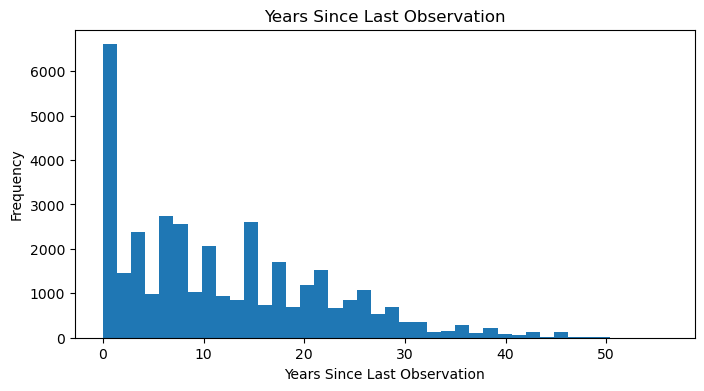

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(population_metrics["years_since_last_obs"], bins=40)

plt.title("Years Since Last Observation")
plt.xlabel("Years Since Last Observation")
plt.ylabel("Frequency")

plt.show()

In [133]:
display(population_metrics["years_since_last_obs"].describe())

count    35980.000000
mean        11.933963
std         10.166229
min          0.000000
25%          4.000000
50%         10.000000
75%         19.000000
max         56.000000
Name: years_since_last_obs, dtype: float64

In [134]:
print("Records reaching 2020:", (population_metrics["years_since_last_obs"] == 0).sum())
print("Records within last 5 years:", (population_metrics["years_since_last_obs"] <= 5).sum())
print("Records within last 10 years:", (population_metrics["years_since_last_obs"] <= 10).sum())

Records reaching 2020: 4723
Records within last 5 years: 11422
Records within last 10 years: 19025


*Why this is important*

Forecasting assumes recent ecological dynamics still apply.

Very old series may reflect:
- outdated climate conditions
- different land use
- historical monitoring methods

So common filtering rules are:

- last_obs_year ≥ 2015
or
- years_since_last_obs ≤ 5

---
# **6 - METADATA QUALITY FLAGS**

This section creates record-level usability indicators that describe whether each population record has the minimum metadata needed for filtering, analysis and modeling.

These flags are useful because they let you later filter datasets without repeatedly checking raw columns.

Examples:

- has coordinates
- has country
- has taxonomic identifiers
- has usable unit information
- belongs to a known system group

They should be added to your existing population_metrics table, because that table is becoming the central filtering table for the project.

### 6.1 - GEOGRAPHIC COMPLETENESS

Geographic metadata is important for:

- spatial analysis
- geographic filtering
- climate enrichment
- map-based application outputs

In this section we create simple geographic completeness flags describing whether each population record includes:

- valid coordinates
- country information

These indicators will later support filtering and metadata quality assessment.
Code cell

In [135]:
# 6.1 Geographic Completeness
# Create geographic metadata flags at the population-record level

# We use the wide dataset because each row already represents one population record

geo_flags = df[["id", "latitude", "longitude", "country"]].copy()

# Coordinate completeness:
# valid only if both latitude and longitude are present
geo_flags["has_coordinates"] = (
    geo_flags["latitude"].notna() &
    geo_flags["longitude"].notna()
)

# Country completeness:
# valid if country exists and is not just missing
geo_flags["has_country"] = geo_flags["country"].notna()

# Optional stricter coordinate validity check
geo_flags["valid_latitude"] = geo_flags["latitude"].between(-90, 90, inclusive="both")
geo_flags["valid_longitude"] = geo_flags["longitude"].between(-180, 180, inclusive="both")

geo_flags["has_valid_coordinates"] = (
    geo_flags["has_coordinates"] &
    geo_flags["valid_latitude"] &
    geo_flags["valid_longitude"]
)

# Keep only the relevant output columns
geo_flags = geo_flags[
    ["id", "has_coordinates", "has_country", "has_valid_coordinates"]
]

# Merge into population_metrics
population_metrics = population_metrics.merge(
    geo_flags,
    on="id",
    how="left"
)

# Quick inspection
display(population_metrics.head())

print("Geographic completeness summary:")
print(f"Records with coordinates: {population_metrics['has_coordinates'].sum():,}")
print(f"Records with valid coordinates: {population_metrics['has_valid_coordinates'].sum():,}")
print(f"Records with country: {population_metrics['has_country'].sum():,}")

display(
    population_metrics[
        ["has_coordinates", "has_valid_coordinates", "has_country"]
    ].mean()
    .rename("share_true")
    .to_frame()
)

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates
0,1,3,1985,2002,18,2,9,0.166667,0,0.0,18,True,True,True
1,2,3,1958,1987,30,2,16,0.100000,0,0.0,33,True,True,True
2,3,6,1977,1990,14,3,5,0.428571,0,0.0,30,True,True,True
3,4,14,1976,1990,15,1,1,0.933333,0,0.0,30,True,True,True
4,5,25,1973,1997,25,0,0,1.000000,0,0.0,23,True,True,True


Geographic completeness summary:
Records with coordinates: 35,980
Records with valid coordinates: 35,980
Records with country: 35,980


,share_true
has_coordinates,1.0
has_valid_coordinates,1.0
has_country,1.0


### 6.2 - TAXONOMIC COMPLETENESS

Taxonomic metadata provides the biological identity and classification of each monitored population.

In this section we create taxonomic completeness flags describing whether each record includes:

- a binomial name
- a taxonomic class
- a basic taxonomic hierarchy

These indicators will support:
- biological interpretation
- taxonomic filtering
- metadata quality assessment
- potential taxonomic model features

In [136]:
# 6.2 Taxonomic Completeness
# Create taxonomic completeness flags at the population-record level

taxonomy_flags = df[
    ["id", "binomial", "class", "order", "family", "genus", "species"]
].copy()

# Basic taxonomic presence flags
taxonomy_flags["has_binomial"] = taxonomy_flags["binomial"].notna()
taxonomy_flags["has_class"] = taxonomy_flags["class"].notna()
taxonomy_flags["has_order"] = taxonomy_flags["order"].notna()
taxonomy_flags["has_family"] = taxonomy_flags["family"].notna()
taxonomy_flags["has_genus"] = taxonomy_flags["genus"].notna()
taxonomy_flags["has_species"] = taxonomy_flags["species"].notna()

# Taxonomy hierarchy flag:
# here we define it as having class + order + family + genus + species
taxonomy_flags["has_taxonomy_hierarchy"] = (
    taxonomy_flags["has_class"] &
    taxonomy_flags["has_order"] &
    taxonomy_flags["has_family"] &
    taxonomy_flags["has_genus"] &
    taxonomy_flags["has_species"]
)

# Keep only relevant output columns
taxonomy_flags = taxonomy_flags[
    [
        "id",
        "has_binomial",
        "has_class",
        "has_order",
        "has_family",
        "has_genus",
        "has_species",
        "has_taxonomy_hierarchy"
    ]
]

# Merge into population_metrics
population_metrics = population_metrics.merge(
    taxonomy_flags,
    on="id",
    how="left"
)

# Quick inspection
display(population_metrics.head())

print("Taxonomic completeness summary:")
print(f"Records with binomial: {population_metrics['has_binomial'].sum():,}")
print(f"Records with class: {population_metrics['has_class'].sum():,}")
print(f"Records with full taxonomy hierarchy: {population_metrics['has_taxonomy_hierarchy'].sum():,}")

display(
    population_metrics[
        [
            "has_binomial",
            "has_class",
            "has_order",
            "has_family",
            "has_genus",
            "has_species",
            "has_taxonomy_hierarchy"
        ]
    ]
    .mean()
    .rename("share_true")
    .to_frame()
)

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy
0,1,3,1985,2002,18,2,9,0.166667,0,0.0,18,True,True,True,True,True,True,True,True,True,True
1,2,3,1958,1987,30,2,16,0.100000,0,0.0,33,True,True,True,True,True,True,True,True,True,True
2,3,6,1977,1990,14,3,5,0.428571,0,0.0,30,True,True,True,True,True,True,True,True,True,True
3,4,14,1976,1990,15,1,1,0.933333,0,0.0,30,True,True,True,True,True,True,True,True,True,True
4,5,25,1973,1997,25,0,0,1.000000,0,0.0,23,True,True,True,True,True,True,True,True,True,True


Taxonomic completeness summary:
Records with binomial: 35,980
Records with class: 35,980
Records with full taxonomy hierarchy: 35,980


,share_true
has_binomial,1.0
has_class,1.0
has_order,1.0
has_family,1.0
has_genus,1.0
has_species,1.0
has_taxonomy_hierarchy,1.0


### 6.3 - UNIT QUALITY FLAGS

Population values are only meaningful if their measurement units are interpretable.

The WWF Living Planet Database contains heterogeneous unit types, which may include:

- direct counts
- breeding pairs or nests
- indices or relative measures
- ambiguous or unclear measurements

In this section we create first-pass unit quality flags to support later filtering.

Outputs include:

- `unit_category`: broad classification of the unit type
- `unit_usable`: whether the unit is considered usable for modeling under a conservative first-pass rule

In [137]:
# 6.3 Unit Quality Flags
# Create a first-pass classification of measurement units

unit_flags = df[["id", "units"]].copy()

def classify_unit(unit_value):
    """
    First-pass broad classification of unit types.
    This is intentionally conservative and can be refined later.
    """
    if pd.isna(unit_value):
        return "missing"
    
    unit = str(unit_value).strip().lower()

    # Direct count / abundance-like units
    direct_count_keywords = [
        "individual", "individuals", "count", "counts",
        "birds", "fish", "adults", "animals",
        "pairs", "breeding pairs", "nests", "territories"
    ]

    # Relative / index-like / non-direct units
    index_keywords = [
        "index", "indices", "relative", "ratio", "percent",
        "density", "abundance index", "cpue"
    ]

    # Ambiguous / difficult-to-compare units
    ambiguous_keywords = [
        "occurrence", "presence", "proxy", "unknown",
        "number", "estimate", "score"
    ]

    if any(keyword in unit for keyword in direct_count_keywords):
        return "direct_count"
    elif any(keyword in unit for keyword in index_keywords):
        return "index_or_relative"
    elif any(keyword in unit for keyword in ambiguous_keywords):
        return "ambiguous"
    else:
        return "other_or_unclear"


unit_flags["unit_category"] = unit_flags["units"].apply(classify_unit)

# Conservative first-pass usability rule:
# usable only if unit is direct_count
unit_flags["unit_usable"] = unit_flags["unit_category"] == "direct_count"

# Quick inspection
display(unit_flags.head())

print("Unit category distribution:")
display(unit_flags["unit_category"].value_counts(dropna=False))

print("Usable unit counts:")
display(unit_flags["unit_usable"].value_counts(dropna=False))

,id,units,unit_category,unit_usable
0,1,mean number of counts per route,direct_count,True
1,2,individuals,direct_count,True
2,3,total population number,ambiguous,False
3,4,number of individuals,direct_count,True
4,5,number of breeding pairs,direct_count,True


Unit category distribution:


unit_category
direct_count         24930
index_or_relative     5111
other_or_unclear      3913
ambiguous             1969
missing                 73
Name: count, dtype: int64

Usable unit counts:


unit_usable
True     24930
False    11066
Name: count, dtype: int64

In [138]:
# Merge unit flags into population_metrics

population_metrics = population_metrics.merge(
    unit_flags[["id", "unit_category", "unit_usable"]],
    on="id",
    how="left"
)

display(population_metrics.head())

print("Share of usable units:")
display(
    population_metrics["unit_usable"]
    .mean()
)

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable
0,1,3,1985,2002,18,2,9,0.166667,0,0.0,18,True,True,True,True,True,True,True,True,True,True,direct_count,True
1,2,3,1958,1987,30,2,16,0.100000,0,0.0,33,True,True,True,True,True,True,True,True,True,True,direct_count,True
2,3,6,1977,1990,14,3,5,0.428571,0,0.0,30,True,True,True,True,True,True,True,True,True,True,ambiguous,False
3,4,14,1976,1990,15,1,1,0.933333,0,0.0,30,True,True,True,True,True,True,True,True,True,True,direct_count,True
4,5,25,1973,1997,25,0,0,1.000000,0,0.0,23,True,True,True,True,True,True,True,True,True,True,direct_count,True


Share of usable units:


np.float64(0.6924402445803224)

In [139]:
unit_flags["unit_category"].value_counts()

unit_category
direct_count         24930
index_or_relative     5111
other_or_unclear      3913
ambiguous             1969
missing                 73
Name: count, dtype: int64

In [140]:
df["units"].value_counts().head(30)

units
sample: abundance (counts)                                   9066
number of individuals                                        2873
average number of individuals                                1986
individuals                                                  1471
annual index                                                 1238
catch per tow                                                 957
cpue (number of individuals observed/number of transects)     670
annual index of population change                             649
number of breeding pairs                                      519
cpue (weight/ (minute towed*tow length))                      443
index                                                         408
sample: density (counts/fixed areas)                          371
number of nests                                               282
estimated number of individuals                               268
biomass (kg)                                                  267
bree

A first-pass unit classification was created to distinguish direct-count style measurements from index-based or ambiguous units. This does not fully resolve unit comparability, but it provides a practical basis for generating modeling subsets with stricter unit consistency.

### 6.4 - SYSTEM CLASSIFICATION

A first-pass unit classification was created to distinguish direct-count style measurements from index-based or ambiguous units. This does not fully resolve unit comparability, but it provides a practical basis for generating modeling subsets with stricter unit consistency.

In [141]:
# 6.4 System Classification

# Inspect raw system values
system_df = df[["id", "system"]].copy()

print("Raw system distribution:")
display(system_df["system"].value_counts(dropna=False))


# Standardize system labels
def classify_system(system_value):

    if pd.isna(system_value):
        return "unknown"

    system = str(system_value).strip().lower()

    if "terrestrial" in system:
        return "terrestrial"

    elif "freshwater" in system:
        return "freshwater"

    elif "marine" in system:
        return "marine"

    else:
        return "other_or_unclear"


system_df["system_group"] = system_df["system"].apply(classify_system)

print("Standardized system distribution:")
display(system_df["system_group"].value_counts(dropna=False))


# Merge system classification into population_metrics
population_metrics = population_metrics.merge(
    system_df[["id", "system_group"]],
    on="id",
    how="left"
)

display(population_metrics.head())


# Quick share summary
print("System group shares:")
display(
    population_metrics["system_group"]
    .value_counts(normalize=True)
)

Raw system distribution:


system
marine         16258
terrestrial    11858
freshwater      7880
Name: count, dtype: int64

Standardized system distribution:


system_group
marine         16258
terrestrial    11858
freshwater      7880
Name: count, dtype: int64

,id,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,1,3,1985,2002,18,2,9,0.166667,0,0.0,18,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
1,2,3,1958,1987,30,2,16,0.100000,0,0.0,33,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
2,3,6,1977,1990,14,3,5,0.428571,0,0.0,30,True,True,True,True,True,True,True,True,True,True,ambiguous,False,terrestrial
3,4,14,1976,1990,15,1,1,0.933333,0,0.0,30,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
4,5,25,1973,1997,25,0,0,1.000000,0,0.0,23,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial


System group shares:


system_group
marine         0.451862
terrestrial    0.329433
freshwater     0.218705
Name: proportion, dtype: float64

---
# **7 - EXPLORATORY DATA QUALITY ANALYSIS**

In this section we visually inspect key dataset properties to validate the
time-series metrics and metadata flags computed earlier.

The goal is to understand the structure of the dataset before defining
filtering policies and generating modeling subsets.

The analysis focuses on:

- observation length
- time-series continuity
- temporal coverage
- taxonomic representation
- geographic coverage
- population value distributions
- measurement units

These visualizations help justify preprocessing decisions and filtering rules.

### 7.1 - OBSERVATION LENGTH DISTRIBUTION

We inspect the distribution of observation counts (`n_obs`) across population records.

This helps determine reasonable thresholds for forecasting tasks.

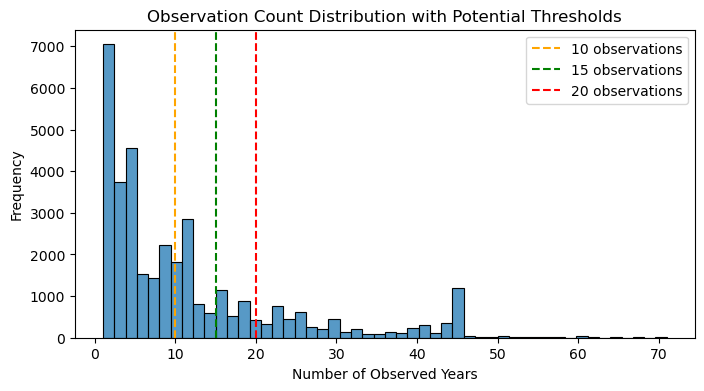

In [142]:
plt.figure(figsize=(8,4))

sns.histplot(population_metrics["n_obs"], bins=50)

plt.axvline(10, color="orange", linestyle="--", label="10 observations")
plt.axvline(15, color="green", linestyle="--", label="15 observations")
plt.axvline(20, color="red", linestyle="--", label="20 observations")

plt.title("Observation Count Distribution with Potential Thresholds")
plt.xlabel("Number of Observed Years")
plt.ylabel("Frequency")

plt.legend()

plt.show()

### 7.2 - CONTINUITY AND GAP ANALYSIS

We inspect time-series continuity and gaps to understand how fragmented
population records are.

Two metrics are analyzed:

- `continuity_ratio`: proportion of observed years within the time span
- `max_gap`: largest gap between observations

These metrics help determine whether time series are suitable for forecasting.

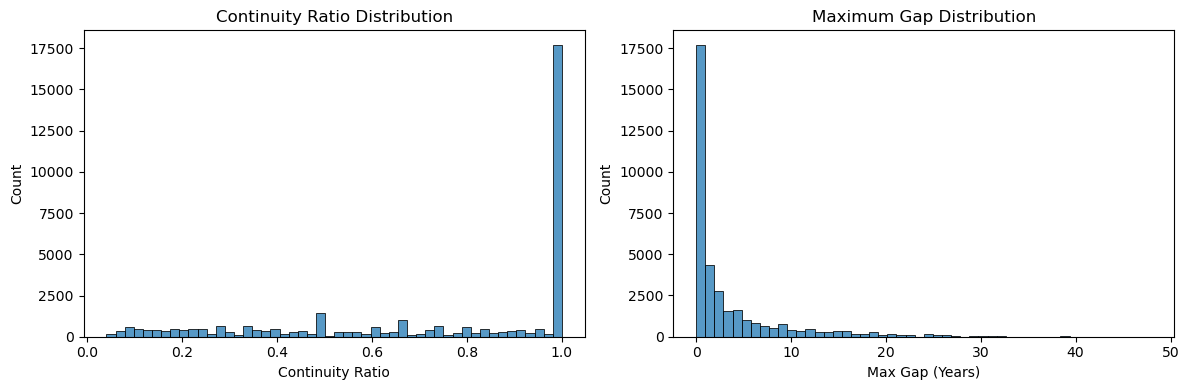

,continuity_ratio,max_gap
count,35980.000000,35980.000000
mean,0.745107,3.301723
std,0.314243,5.899325
min,0.040000,0.000000
25%,0.500000,0.000000
50%,0.958333,1.000000
75%,1.000000,4.000000
max,1.000000,48.000000


In [143]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(population_metrics["continuity_ratio"], bins=50, ax=axes[0])
axes[0].set_title("Continuity Ratio Distribution")
axes[0].set_xlabel("Continuity Ratio")

sns.histplot(population_metrics["max_gap"], bins=50, ax=axes[1])
axes[1].set_title("Maximum Gap Distribution")
axes[1].set_xlabel("Max Gap (Years)")

plt.tight_layout()
plt.show()

display(
    population_metrics[["continuity_ratio","max_gap"]].describe()
)

### 7.3 - TEMPORAL COVERAGE

We examine how population observations are distributed across time.

This helps identify monitoring bias across decades and confirms
the strong increase in monitoring effort in recent decades.

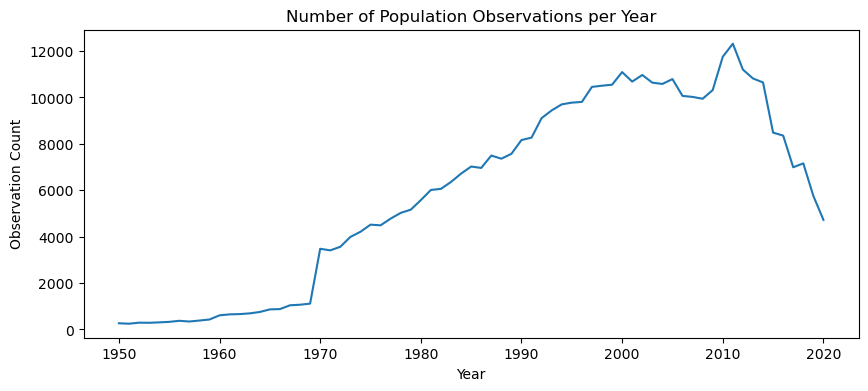

In [144]:
# observations per year

year_counts = df_long["year"].value_counts().sort_index()

plt.figure(figsize=(10,4))

plt.plot(year_counts.index, year_counts.values)

plt.title("Number of Population Observations per Year")
plt.xlabel("Year")
plt.ylabel("Observation Count")

plt.show()

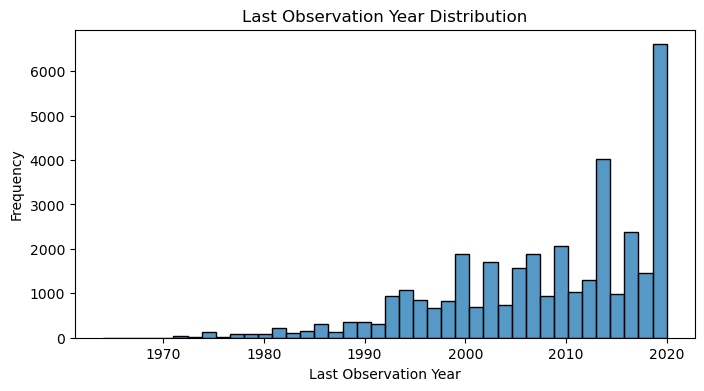

In [145]:
plt.figure(figsize=(8,4))

sns.histplot(population_metrics["last_obs_year"], bins=40)

plt.title("Last Observation Year Distribution")
plt.xlabel("Last Observation Year")
plt.ylabel("Frequency")

plt.show()

### 7.4 - TAXONOMIC DISTRIBUTION

We inspect the taxonomic composition of the dataset to understand
representation across biological classes and species.

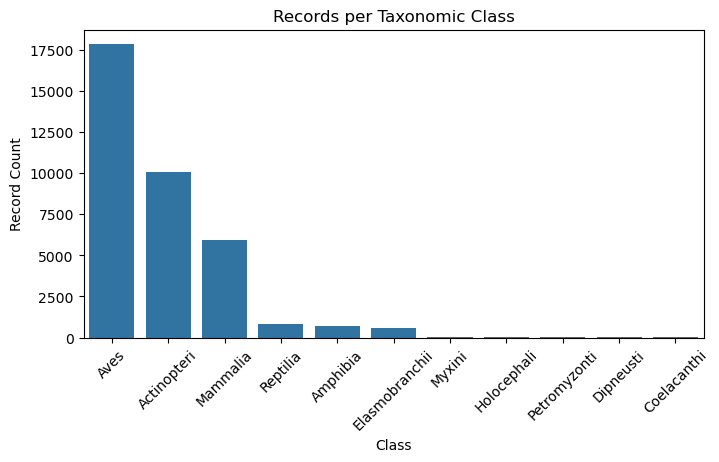

In [146]:
class_counts = df["class"].value_counts()

plt.figure(figsize=(8,4))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Records per Taxonomic Class")
plt.xlabel("Class")
plt.ylabel("Record Count")

plt.xticks(rotation=45)

plt.show()

### 7.5 - GEOGRAPHIC DISTRIBUTION

We inspect the geographic coverage of the dataset by country
and confirm the global distribution of monitored populations.

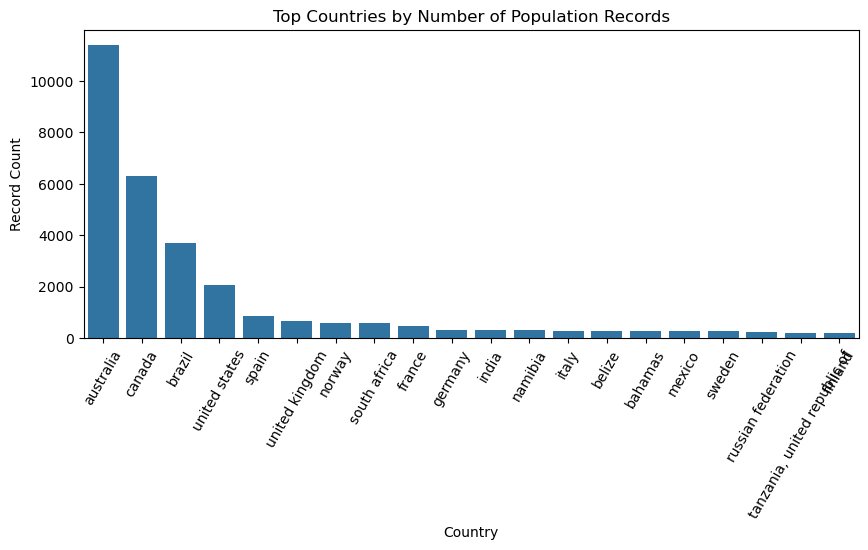

In [147]:
country_counts = df["country"].value_counts().head(20)

plt.figure(figsize=(10,4))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.title("Top Countries by Number of Population Records")
plt.xlabel("Country")
plt.ylabel("Record Count")

plt.xticks(rotation=60)

plt.show()

### 7.6 - POPULATION VALUE DISTRIBUTION

Population values vary across several orders of magnitude.

We inspect both the raw distribution and a log-transformed version
to better understand the scale of the data.

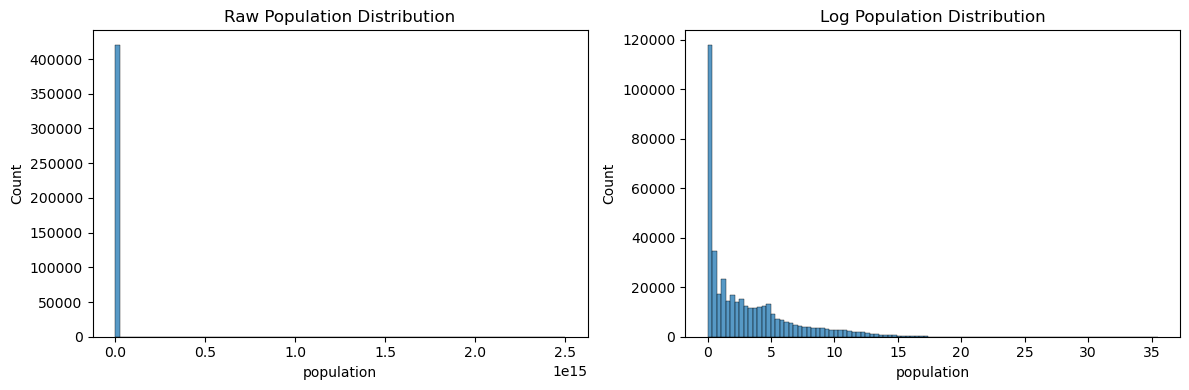

In [148]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df_long["population"], bins=100, ax=axes[0])
axes[0].set_title("Raw Population Distribution")

sns.histplot(np.log1p(df_long["population"]), bins=100, ax=axes[1])
axes[1].set_title("Log Population Distribution")

plt.tight_layout()
plt.show()

### 7.7 - UNITS DISTRIBUTION

We inspect the distribution of measurement units to understand
how heterogeneous population measurements are across records.

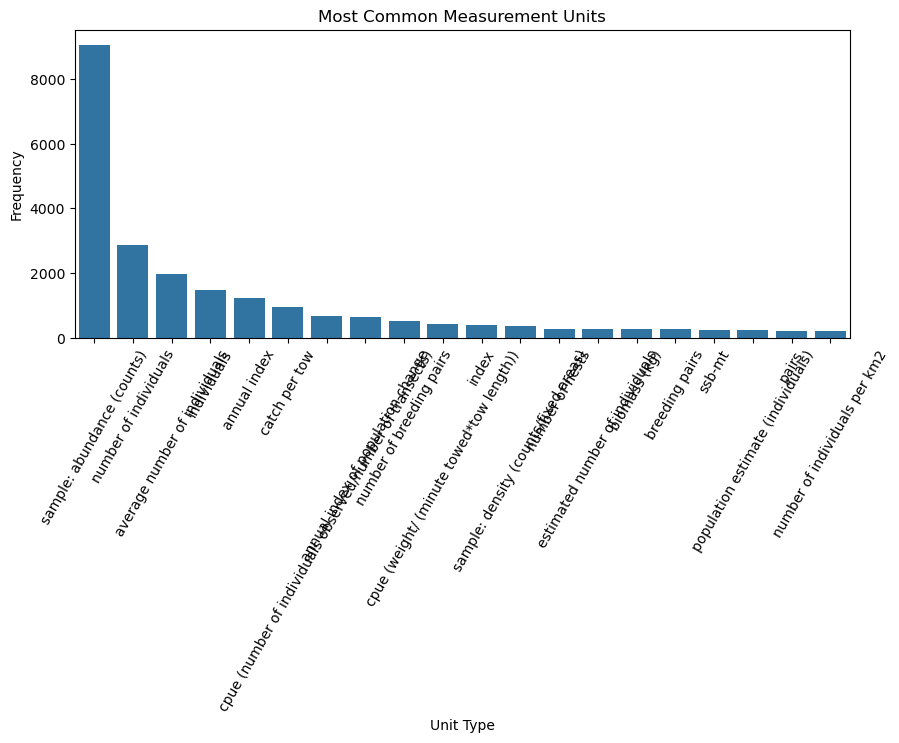

units
sample: abundance (counts)                                   9066
number of individuals                                        2873
average number of individuals                                1986
individuals                                                  1471
annual index                                                 1238
catch per tow                                                 957
cpue (number of individuals observed/number of transects)     670
annual index of population change                             649
number of breeding pairs                                      519
cpue (weight/ (minute towed*tow length))                      443
index                                                         408
sample: density (counts/fixed areas)                          371
number of nests                                               282
estimated number of individuals                               268
biomass (kg)                                                  267
bree

In [149]:
unit_counts = df["units"].value_counts().head(20)

plt.figure(figsize=(10,4))

sns.barplot(
    x=unit_counts.index,
    y=unit_counts.values
)

plt.title("Most Common Measurement Units")
plt.xlabel("Unit Type")
plt.ylabel("Frequency")

plt.xticks(rotation=60)

plt.show()

display(unit_counts)

---
# **8 - DEFINE DATASET FILTERING POLICIES**

This section defines the rules used to generate different dataset variants
for modeling experiments.

The WWF Living Planet dataset contains heterogeneous time-series data
with varying quality, measurement units and ecological contexts.

Rather than producing a single cleaned dataset, we define multiple
filtering policies across several dimensions:

- ecological system scope
- time-series quality
- recency of observations
- measurement units
- geographic coverage
- handling of zero-heavy series

These policies will later be combined to generate multiple dataset variants
for experimentation and model comparison.

### 8.1 - ECOLOGICAL SCOPE FILTERS

The Living Planet Database includes populations from multiple ecological systems:

- terrestrial
- freshwater
- marine

Different modeling scopes may focus on different systems.

Examples:

- terrestrial-only datasets (aligned with SDG 15)
- aquatic datasets (marine + freshwater, aligned with SDG 14)
- global biodiversity datasets (all systems)

We define reusable system filters that will later be applied
when generating dataset variants.

In [150]:
# 8.1 Ecological Scope Filters

# Inspect system distribution again
print("System group distribution:")
display(
    population_metrics["system_group"]
    .value_counts(dropna=False)
)


# Define ecological scope filters
system_filters = {

    "all_systems":
        population_metrics["system_group"].notna(),

    "terrestrial_only":
        population_metrics["system_group"] == "terrestrial",

    "aquatic_only":
        population_metrics["system_group"].isin(["marine", "freshwater"]),

    "marine_only":
        population_metrics["system_group"] == "marine",

    "freshwater_only":
        population_metrics["system_group"] == "freshwater"
}


# Quick size comparison
for name, mask in system_filters.items():

    print(
        f"{name}:",
        mask.sum(),
        "records"
    )

System group distribution:


system_group
marine         16258
terrestrial    11853
freshwater      7869
Name: count, dtype: int64

all_systems: 35980 records
terrestrial_only: 11853 records
aquatic_only: 24127 records
marine_only: 16258 records
freshwater_only: 7869 records


### 8.2 - TIME-SERIES QUALITY THRESHOLDS

Time-series quality is one of the main determinants of whether a population record
is suitable for forecasting.

In this subsection we define reusable filtering policies based on:

- number of observations
- maximum internal gap length
- continuity ratio

These policies will later be combined with other filtering dimensions
to generate multiple dataset variants.

Time-series quality is one of the main determinants of whether a population record
is suitable for forecasting.

In this subsection we define reusable filtering policies based on:

- number of observations
- maximum internal gap length
- continuity ratio

These policies will later be combined with other filtering dimensions
to generate multiple dataset variants.

In [151]:
# 8.2 Time-Series Quality Thresholds

print("Current time-series metric summary:")
display(
    population_metrics[["n_obs", "max_gap", "continuity_ratio"]].describe()
)

time_quality_filters = {
    "loose": (
        (population_metrics["n_obs"] >= 10) &
        (population_metrics["max_gap"] <= 3) &
        (population_metrics["continuity_ratio"] >= 0.5)
    ),
    "balanced": (
        (population_metrics["n_obs"] >= 15) &
        (population_metrics["max_gap"] <= 2) &
        (population_metrics["continuity_ratio"] >= 0.7)
    ),
    "strict": (
        (population_metrics["n_obs"] >= 20) &
        (population_metrics["max_gap"] <= 1) &
        (population_metrics["continuity_ratio"] >= 0.8)
    )
}

print("Records passing each time-series quality policy:")
for name, mask in time_quality_filters.items():
    print(f"{name}: {mask.sum():,}")

Current time-series metric summary:


,n_obs,max_gap,continuity_ratio
count,35980.000000,35980.000000,35980.000000
mean,11.683046,3.301723,0.745107
std,12.021634,5.899325,0.314243
min,1.000000,0.000000,0.040000
25%,3.000000,0.000000,0.500000
50%,7.000000,1.000000,0.958333
75%,15.000000,4.000000,1.000000
max,71.000000,48.000000,1.000000


Records passing each time-series quality policy:
loose: 13,239
balanced: 7,882
strict: 5,727


### 8.3 - RECENCY FILTERS

Forecasting is more credible when population records include recent observations.

In this subsection we define reusable recency filters based on:

- last observation year
- years since last observation

These filters help distinguish recent time series from outdated ones.

In [152]:
# 8.3 Recency Filters

print("Recency summary:")
display(
    population_metrics[["last_obs_year", "years_since_last_obs"]].describe()
)

recency_filters = {
    "last2010plus": population_metrics["last_obs_year"] >= 2010,
    "last2015plus": population_metrics["last_obs_year"] >= 2015,
    "last2020": population_metrics["last_obs_year"] == 2020
}

print("Records passing each recency policy:")
for name, mask in recency_filters.items():
    print(f"{name}: {mask.sum():,}")

Recency summary:


,last_obs_year,years_since_last_obs
count,35980.000000,35980.000000
mean,2008.066037,11.933963
std,10.166229,10.166229
min,1964.000000,0.000000
25%,2001.000000,4.000000
50%,2010.000000,10.000000
75%,2016.000000,19.000000
max,2020.000000,56.000000


Records passing each recency policy:
last2010plus: 19,025
last2015plus: 11,422
last2020: 4,723


### 8.4 - UNIT FILTERING POLICIES

Population measurements are not always directly comparable because the dataset
contains heterogeneous unit types.

In this subsection we define reusable unit filtering policies based on the
first-pass unit classification created earlier.

These policies will later support the generation of datasets with different
levels of unit consistency.

In [153]:
# 8.4 Unit Filtering Policies

print("Unit category distribution:")
display(population_metrics["unit_category"].value_counts(dropna=False))

unit_filters = {
    "units_all": population_metrics["unit_category"].notna(),
    "units_usable": population_metrics["unit_usable"] == True,
    "units_direct_only": population_metrics["unit_category"] == "direct_count"
}

print("Records passing each unit policy:")
for name, mask in unit_filters.items():
    print(f"{name}: {mask.sum():,}")

Unit category distribution:


unit_category
direct_count         24914
index_or_relative     5111
other_or_unclear      3913
ambiguous             1969
missing                 73
Name: count, dtype: int64

Records passing each unit policy:
units_all: 35,980
units_usable: 24,914
units_direct_only: 24,914


### 8.5 - GEOGRAPHIC FILTERING POLICIES

Geographic filtering can be useful for creating smaller, stronger modeling subsets.

In this subsection we define reusable geographic policies such as:

- global coverage
- top countries by number of records
- strong-coverage countries

These filters may help reduce heterogeneity and improve modeling feasibility.

In [154]:
# 8.5 Geographic Filtering Policies

country_counts = df["country"].value_counts(dropna=True)

top10_countries = country_counts.head(10).index.tolist()

# Simple first-pass definition of "strong coverage countries":
# countries with at least 100 records in the raw dataset
strong_coverage_countries = country_counts[country_counts >= 100].index.tolist()

print("Top 10 countries:")
print(top10_countries)

print("\nStrong coverage countries (>=100 records):")
print(strong_coverage_countries)

geo_filters = {
    "global": population_metrics["id"].notna(),
    "top10countries": df.set_index("id").loc[population_metrics["id"], "country"].isin(top10_countries).values,
    "strongcountries": df.set_index("id").loc[population_metrics["id"], "country"].isin(strong_coverage_countries).values
}

print("\nRecords passing each geographic policy:")
for name, mask in geo_filters.items():
    print(f"{name}: {mask.sum():,}")

Top 10 countries:
['australia', 'canada', 'brazil', 'united states', 'spain', 'united kingdom', 'norway', 'south africa', 'france', 'germany']

Strong coverage countries (>=100 records):
['australia', 'canada', 'brazil', 'united states', 'spain', 'united kingdom', 'norway', 'south africa', 'france', 'germany', 'india', 'namibia', 'italy', 'belize', 'bahamas', 'mexico', 'sweden', 'russian federation', 'tanzania, united republic of', 'finland', 'kenya', 'uganda', 'international waters', 'türkiye', 'new zealand', 'cameroon', 'poland', 'ukraine', 'antarctica', 'taiwan, province of china', 'czechia', 'argentina', 'netherlands', 'denmark', 'morocco', 'zimbabwe', 'botswana', 'romania', 'greece']

Records passing each geographic policy:
global: 35,980
top10countries: 26,939
strongcountries: 32,258


### 8.6 - ZERO HANDLING POLICIES

Zero population values may represent extinction, non-detection, or recording artifacts.

Rather than applying a single rigid rule, we define reusable zero-handling
policies that allow later dataset variants to either:

- keep all records
- flag zero-heavy series
- exclude potentially problematic zero-heavy series

In [155]:
# 8.6 Zero Handling Policies

print("Zero-share summary:")
display(population_metrics["zero_share"].describe())

zero_filters = {
    "zeros_keep": population_metrics["id"].notna(),
    "zeros_not_heavy": population_metrics["zero_share"] <= 0.3,
    "zeros_strict": population_metrics["zero_share"] <= 0.1
}

print("Records passing each zero policy:")
for name, mask in zero_filters.items():
    print(f"{name}: {mask.sum():,}")

Zero-share summary:


count    35980.000000
mean         0.166797
std          0.287652
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          1.000000
Name: zero_share, dtype: float64

Records passing each zero policy:
zeros_keep: 35,980
zeros_not_heavy: 27,369
zeros_strict: 25,403


### 8.7 - DATASET VARIANT CONFIGURATION REGISTRY

Before generating dataset variants, we define a central configuration
registry listing all dataset variants to be produced.

Each entry specifies the filtering rules applied and the folder in which
the dataset will be saved.

This registry ensures that dataset generation remains transparent,
reproducible and easy to modify.

In [156]:
DATASET_CONFIGS = {
    "broad_exploration": {
        "lpd_all_loose_last2010_unitsall_global_zeroskeep": {
            "system_scope": "all_systems",
            "quality_level": "loose",
            "recency_level": "last2010plus",
            "unit_level": "units_all",
            "geo_level": "global",
            "zero_level": "zeros_keep"
        },
        "lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep": {
            "system_scope": "terrestrial_only",
            "quality_level": "loose",
            "recency_level": "last2010plus",
            "unit_level": "units_all",
            "geo_level": "global",
            "zero_level": "zeros_keep"
        }
    },

    "balanced_forecasting": {
        "lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep": {
            "system_scope": "terrestrial_only",
            "quality_level": "balanced",
            "recency_level": "last2015plus",
            "unit_level": "units_usable",
            "geo_level": "global",
            "zero_level": "zeros_keep"
        },
        "lpd_all_balanced_last2015_unitsusable_global_zeroskeep": {
            "system_scope": "all_systems",
            "quality_level": "balanced",
            "recency_level": "last2015plus",
            "unit_level": "units_usable",
            "geo_level": "global",
            "zero_level": "zeros_keep"
        }
    },

    "strict_forecasting": {
        "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep": {
            "system_scope": "terrestrial_only",
            "quality_level": "strict",
            "recency_level": "last2020",
            "unit_level": "units_usable",
            "geo_level": "global",
            "zero_level": "zeros_keep"
        },
        "lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy": {
            "system_scope": "terrestrial_only",
            "quality_level": "strict",
            "recency_level": "last2020",
            "unit_level": "units_direct_only",
            "geo_level": "global",
            "zero_level": "zeros_not_heavy"
        }
    },

    "risk_decline": {
        "lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk": {
            "system_scope": "terrestrial_only",
            "quality_level": "loose",
            "recency_level": "last2015plus",
            "unit_level": "units_all",
            "geo_level": "global",
            "zero_level": "zeros_keep"
        }
    },

    "geographic_subsets": {
        "lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep": {
            "system_scope": "terrestrial_only",
            "quality_level": "balanced",
            "recency_level": "last2015plus",
            "unit_level": "units_usable",
            "geo_level": "top10countries",
            "zero_level": "zeros_keep"
        }
    }
}

---
# **9 - DATASET VARIANT GENERATION**

In this section we generate multiple dataset variants based on the filtering
policies defined earlier.

The goal is to provide several candidate datasets for modeling experiments,
rather than forcing a single preprocessing decision.

Each dataset variant combines filters across several dimensions:

- ecological system scope
- time-series quality thresholds
- recency requirements
- measurement unit policies
- geographic filtering
- zero-value handling

All generated datasets will be saved to the `data/interim/` directory.

### 9.1 - EXPORT STRATEGY

To keep dataset generation reproducible and organized, we use:

- a standardized naming convention
- a helper function to build filtering masks
- a helper function to export datasets
- a manifest table to track all exported variants

Naming convention:

lpd_[system]_[quality]_[recency]_[units]_[geo]_[zeros]

Example:

lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep

All generated datasets will be saved to the `data/interim/` directory.

In [ ]:
# 9.1 Export Strategy

from pathlib import Path
import pandas as pd

# Ensure interim folder exists
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

# Master dataset for export
df_with_metrics = df.merge(
    population_metrics,
    on="id",
    how="left"
).copy()

print("Master dataset with metrics shape:", df_with_metrics.shape)
display(df_with_metrics.head())


def build_filter_mask(
    df,
    system_scope="all_systems",
    quality_level=None,
    recency_level=None,
    unit_level=None,
    geo_level=None,
    zero_level=None
):
    """
    Build a boolean mask directly on df_with_metrics.
    """

    mask = pd.Series(True, index=df.index)

    # 1. Ecological scope
    if system_scope == "terrestrial_only":
        mask &= df["system_group"] == "terrestrial"
    elif system_scope == "aquatic_only":
        mask &= df["system_group"].isin(["marine", "freshwater"])
    elif system_scope == "marine_only":
        mask &= df["system_group"] == "marine"
    elif system_scope == "freshwater_only":
        mask &= df["system_group"] == "freshwater"
    elif system_scope == "all_systems":
        mask &= df["system_group"].notna()

    # 2. Time-series quality
    if quality_level == "loose":
        mask &= (
            (df["n_obs"] >= 10) &
            (df["max_gap"] <= 3) &
            (df["continuity_ratio"] >= 0.5)
        )
    elif quality_level == "balanced":
        mask &= (
            (df["n_obs"] >= 15) &
            (df["max_gap"] <= 2) &
            (df["continuity_ratio"] >= 0.7)
        )
    elif quality_level == "strict":
        mask &= (
            (df["n_obs"] >= 20) &
            (df["max_gap"] <= 1) &
            (df["continuity_ratio"] >= 0.8)
        )

    # 3. Recency
    if recency_level == "last2010plus":
        mask &= df["last_obs_year"] >= 2010
    elif recency_level == "last2015plus":
        mask &= df["last_obs_year"] >= 2015
    elif recency_level == "last2020":
        mask &= df["last_obs_year"] == 2020

    # 4. Units
    if unit_level == "units_usable":
        mask &= df["unit_usable"] == True
    elif unit_level == "units_direct_only":
        mask &= df["unit_category"] == "direct_count"
    elif unit_level == "units_all":
        mask &= df["unit_category"].notna()

    # 5. Geography
    if geo_level == "top10countries":
        top10_countries = df["country"].value_counts(dropna=True).head(10).index
        mask &= df["country"].isin(top10_countries)
    elif geo_level == "strongcountries":
        strong_countries = df["country"].value_counts(dropna=True)
        strong_countries = strong_countries[strong_countries >= 100].index
        mask &= df["country"].isin(strong_countries)
    elif geo_level == "global":
        mask &= df["id"].notna()

    # 6. Zero handling
    if zero_level == "zeros_not_heavy":
        mask &= df["zero_share"] <= 0.3
    elif zero_level == "zeros_strict":
        mask &= df["zero_share"] <= 0.1
    elif zero_level == "zeros_keep":
        mask &= df["id"].notna()

    return mask


def summarize_dataset(df_variant, dataset_name, config):
    """
    Create one manifest row summarizing an exported dataset.
    """
    summary = {
        "dataset_name": dataset_name,
        "system_scope": config.get("system_scope"),
        "quality_level": config.get("quality_level"),
        "recency_level": config.get("recency_level"),
        "unit_level": config.get("unit_level"),
        "geo_level": config.get("geo_level"),
        "zero_level": config.get("zero_level"),
        "record_count": len(df_variant),
        "species_count": df_variant["binomial"].nunique() if "binomial" in df_variant.columns else None,
        "country_count": df_variant["country"].nunique() if "country" in df_variant.columns else None,
        "avg_n_obs": df_variant["n_obs"].mean() if "n_obs" in df_variant.columns else None,
        "avg_continuity": df_variant["continuity_ratio"].mean() if "continuity_ratio" in df_variant.columns else None,
        "avg_zero_share": df_variant["zero_share"].mean() if "zero_share" in df_variant.columns else None,
    }
    return summary


def export_dataset_variant(df, dataset_name, config, subfolder):
    """
    Apply filters, export CSV into a subfolder and return summary info.
    """
    mask = build_filter_mask(
        df,
        system_scope=config.get("system_scope", "all_systems"),
        quality_level=config.get("quality_level"),
        recency_level=config.get("recency_level"),
        unit_level=config.get("unit_level"),
        geo_level=config.get("geo_level"),
        zero_level=config.get("zero_level")
    )

    df_variant = df.loc[mask].copy()

    output_dir = INTERIM_DIR / subfolder
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / f"{dataset_name}.csv"
    df_variant.to_csv(output_path, index=False)

    print(f"Saved: {output_path} | records: {len(df_variant):,}")

    summary = summarize_dataset(df_variant, dataset_name, config)
    summary["subfolder"] = subfolder
    summary["file_path"] = str(output_path)

    return df_variant, summary

Master dataset with metrics shape: (35996, 126)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of Uganda's Biodiversity 2002. The State of Uganda's Biodiversity - an an...",Aves,Gruiformes,Gruidae,Balearica,regulorum,NaN,Grey-crowned crane,South-western Uganda,uganda,Uganda,Africa,Africa,East Africa and adjacent islands,-0.07889,31.13306,0,terrestrial,Afrotropical,"Tropical and subtropical grasslands, savannas and shrublands",NaN,NaN,NaN,NaN,NaN,mean number of counts per route,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.5,NaN,NaN,NaN,NaN,NaN,NaN,10.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,3.0,1985.0,2002.0,18.0,2.0,9.0,0.166667,0.0,0.0,18.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush warbler."" Oryx 23(1): 3-Apr.",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,NaN,Seychelles warbler,"Cousin Island, Seychelles",seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.33333,55.66667,1,terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,3.0,1958.0,1987.0,30.0,2.0,16.0,0.100000,0.0,0.0,33.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelles Magpie Robin Copsychus sechellarum and implications for its conserva...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,Seychelles,seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.66667,0,terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,total population number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,41.0,NaN,NaN,21.0,24.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,6.0,1977.0,1990.0,14.0,3.0,5.0,0.428571,0.0,0.0,30.0,True,True,True,True,True,True,True,True,True,True,ambiguous,False,terrestrial
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelles Magpie Robin Copsychus sechellarum and implications for its conserva...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,"Fregate Island, Seychelles",seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.93333,1,terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,N

### 9.2 - BROAD EXPLORATION DATASETS

These datasets apply minimal filtering and preserve a large portion of the
original data.

They are useful for:

- exploratory analysis
- early modeling experiments
- debugging feature engineering pipelines

In [158]:
dataset_manifest = []

broad_configs = {
    "lpd_all_loose_last2010_unitsall_global_zeroskeep": {
        "system_scope": "all_systems",
        "quality_level": "loose",
        "recency_level": "last2010plus",
        "unit_level": "units_all",
        "geo_level": "global",
        "zero_level": "zeros_keep"
    },
    "lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep": {
        "system_scope": "terrestrial_only",
        "quality_level": "loose",
        "recency_level": "last2010plus",
        "unit_level": "units_all",
        "geo_level": "global",
        "zero_level": "zeros_keep"
    }
}

for dataset_name, config in broad_configs.items():
    _, summary = export_dataset_variant(
        df_with_metrics,
        dataset_name,
        config,
        subfolder="broad_exploration"
    )
    dataset_manifest.append(summary)

Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\broad_exploration\lpd_all_loose_last2010_unitsall_global_zeroskeep.csv | records: 8,278
Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\broad_exploration\lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep.csv | records: 2,809


### 9.3 - BALANCED FORECASTING DATASETS

These datasets aim to balance sample size and time-series quality.

They are likely the strongest initial candidates for baseline modeling.

In [159]:
balanced_configs = {
    "lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep": {
        "system_scope": "terrestrial_only",
        "quality_level": "balanced",
        "recency_level": "last2015plus",
        "unit_level": "units_usable",
        "geo_level": "global",
        "zero_level": "zeros_keep"
    },
    "lpd_all_balanced_last2015_unitsusable_global_zeroskeep": {
        "system_scope": "all_systems",
        "quality_level": "balanced",
        "recency_level": "last2015plus",
        "unit_level": "units_usable",
        "geo_level": "global",
        "zero_level": "zeros_keep"
    }
}

for dataset_name, config in balanced_configs.items():
    _, summary = export_dataset_variant(
        df_with_metrics,
        dataset_name,
        config,
        subfolder="balanced_forecasting"
    )
    dataset_manifest.append(summary)

Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\balanced_forecasting\lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv | records: 366
Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\balanced_forecasting\lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv | records: 1,524


### 9.4 - STRICT FORECASTING DATASETS

These datasets apply strong filtering rules to retain only higher-quality
time series that are more suitable for forecasting experiments.

In [160]:
strict_configs = {
    "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep": {
        "system_scope": "terrestrial_only",
        "quality_level": "strict",
        "recency_level": "last2020",
        "unit_level": "units_usable",
        "geo_level": "global",
        "zero_level": "zeros_keep"
    },
    "lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy": {
        "system_scope": "terrestrial_only",
        "quality_level": "strict",
        "recency_level": "last2020",
        "unit_level": "units_direct_only",
        "geo_level": "global",
        "zero_level": "zeros_not_heavy"
    }
}

for dataset_name, config in strict_configs.items():
    _, summary = export_dataset_variant(
        df_with_metrics,
        dataset_name,
        config,
        subfolder="strict_forecasting"
    )
    dataset_manifest.append(summary)

Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv | records: 49
Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\strict_forecasting\lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv | records: 34


### 9.5 - RISK / DECLINE MODELING DATASETS

These datasets are designed for trend analysis, decline detection, or
early-warning style modeling, where looser time-series continuity may still
be acceptable.

In [161]:
risk_configs = {
    "lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk": {
        "system_scope": "terrestrial_only",
        "quality_level": "loose",
        "recency_level": "last2015plus",
        "unit_level": "units_all",
        "geo_level": "global",
        "zero_level": "zeros_keep"
    },
    "lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk": {
        "system_scope": "terrestrial_only",
        "quality_level": "balanced",
        "recency_level": "last2015plus",
        "unit_level": "units_usable",
        "geo_level": "global",
        "zero_level": "zeros_keep"
    }
}

for dataset_name, config in risk_configs.items():
    _, summary = export_dataset_variant(
        df_with_metrics,
        dataset_name,
        config,
        subfolder="risk_decline"
    )
    dataset_manifest.append(summary)

Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\risk_decline\lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk.csv | records: 1,093
Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\risk_decline\lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk.csv | records: 366


### 9.6 - GEOGRAPHIC SUBSETS

These datasets restrict modeling to countries with stronger monitoring
coverage, potentially reducing heterogeneity and improving data consistency.

In [162]:
geo_configs = {
    "lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep": {
        "system_scope": "terrestrial_only",
        "quality_level": "balanced",
        "recency_level": "last2015plus",
        "unit_level": "units_usable",
        "geo_level": "top10countries",
        "zero_level": "zeros_keep"
    },
    "lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep": {
        "system_scope": "terrestrial_only",
        "quality_level": "balanced",
        "recency_level": "last2015plus",
        "unit_level": "units_usable",
        "geo_level": "strongcountries",
        "zero_level": "zeros_keep"
    }
}

for dataset_name, config in geo_configs.items():
    _, summary = export_dataset_variant(
        df_with_metrics,
        dataset_name,
        config,
        subfolder="geographic_subsets"
    )
    dataset_manifest.append(summary)

Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\geographic_subsets\lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv | records: 252
Saved: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\geographic_subsets\lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep.csv | records: 362


---
# **10 - DATASET QUALITY VALIDATION**

After generating the dataset variants, we compare their main properties to
understand how different filtering choices affect:

- dataset size
- taxonomic coverage
- geographic coverage
- time-series quality
- zero-value prevalence
- metadata completeness

This validation step helps identify the most promising datasets for
downstream modeling.

In [167]:
# Build dataset manifest dataframe

manifest_df = pd.DataFrame(dataset_manifest)
manifest_df = manifest_df.sort_values(
    by="record_count",
    ascending=False
)

print("Dataset manifest preview:")
display(manifest_df.head())

print("Number of datasets generated:", len(manifest_df))

Dataset manifest preview:


,dataset_name,system_scope,quality_level,recency_level,unit_level,geo_level,zero_level,record_count,species_count,country_count,avg_n_obs,avg_continuity,avg_zero_share,subfolder,file_path
0,lpd_all_loose_last2010_unitsall_global_zeroskeep,all_systems,loose,last2010plus,units_all,global,zeros_keep,8278,1556,85,24.614883,0.966307,0.276006,broad_exploration,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
1,lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep,terrestrial_only,loose,last2010plus,units_all,global,zeros_keep,2809,618,55,32.253471,0.976013,0.084688,broad_exploration,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
3,lpd_all_balanced_last2015_unitsusable_global_zeroskeep,all_systems,balanced,last2015plus,units_usable,global,zeros_keep,1524,179,26,23.613517,0.958478,0.424550,balanced_forecasting,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
6,lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk,terrestrial_only,loose,last2015plus,units_all,global,zeros_keep,1093,319,40,20.881061,0.951439,0.209831,risk_decline,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
7,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk,terrestrial_only,balanced,last2015plus,units_usable,global,zeros_keep,366,44,17,21.210383,0.982900,0.351462,risk_decline,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...


Number of datasets generated: 10


### 10.1 - DATASET SIZE

After generating the dataset variants, we compare their main properties to
understand how different filtering choices affect:

- dataset size
- taxonomic coverage
- geographic coverage
- time-series quality
- zero-value prevalence
- metadata completeness

This validation step helps identify the most promising datasets for
downstream modeling.

In [165]:
# 10.1 Dataset Size

size_cols = [
    "dataset_name",
    "record_count",
    "species_count",
    "country_count"
]

size_validation = manifest_df[size_cols].sort_values(
    by="record_count",
    ascending=False
)

display(size_validation)

,dataset_name,record_count,species_count,country_count
0,lpd_all_loose_last2010_unitsall_global_zeroskeep,8278,1556,85
1,lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep,2809,618,55
3,lpd_all_balanced_last2015_unitsusable_global_zeroskeep,1524,179,26
6,lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk,1093,319,40
7,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk,366,44,17
2,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep,366,44,17
9,lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep,362,41,13
8,lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep,252,30,7
4,lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep,49,8,5
5,lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy,34,8,5


### 10.2 - TIME-SERIES QUALITY SUMMARY

We compare the average time-series quality across exported datasets.

The main metrics considered are:

- average number of observations per record
- average continuity ratio
- average zero share

These summaries help identify datasets that are stronger candidates for forecasting.

In [168]:
# 10.2 Time-Series Quality Summary

quality_cols = [
    "dataset_name",
    "avg_n_obs",
    "avg_continuity",
    "avg_zero_share"
]

quality_validation = manifest_df[quality_cols].sort_values(
    by="avg_n_obs",
    ascending=False
)

display(quality_validation)

,dataset_name,avg_n_obs,avg_continuity,avg_zero_share
1,lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep,32.253471,0.976013,0.084688
5,lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy,28.088235,0.987000,0.093752
4,lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep,27.530612,0.985921,0.231701
0,lpd_all_loose_last2010_unitsall_global_zeroskeep,24.614883,0.966307,0.276006
3,lpd_all_balanced_last2015_unitsusable_global_zeroskeep,23.613517,0.958478,0.424550
8,lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep,22.769841,0.984019,0.510457
7,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk,21.210383,0.982900,0.351462
2,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep,21.210383,0.982900,0.351462
9,lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep,21.204420,0.982873,0.355346
6,lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk,20.881061,0.951439,0.209831


### 10.3 - POPULATION STATISTICS

We compare the distribution of population values across exported datasets.

The main statistics considered are:

- mean population
- median population
- average zero share

Because raw population values are highly skewed, the median is especially informative.

In [169]:
# 10.3 Population Statistics

population_stats_rows = []

for _, row in manifest_df.iterrows():
    file_path = Path(row["file_path"])
    
    df_variant = pd.read_csv(file_path)
    
    # Identify year columns again
    variant_year_cols = [
        col for col in df_variant.columns
        if str(col).isdigit() and 1900 <= int(col) <= 2100
    ]
    
    # Stack observed population values
    pop_values = (
        df_variant[variant_year_cols]
        .stack()
        .dropna()
    )
    
    population_stats_rows.append({
        "dataset_name": row["dataset_name"],
        "mean_population": pop_values.mean(),
        "median_population": pop_values.median(),
        "zero_share_observed": (pop_values == 0).mean()
    })

population_stats_df = pd.DataFrame(population_stats_rows)

display(population_stats_df.sort_values("median_population", ascending=False))

C:\Users\Vaccari\AppData\Local\Temp\ipykernel_27660\321242187.py:8: DtypeWarning: Columns (10,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_variant = pd.read_csv(file_path)


,dataset_name,mean_population,median_population,zero_share_observed
3,lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk,6.691495e+02,9.00,0.183981
9,lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy,3.571340e+01,4.00,0.089005
8,lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep,2.557991e+01,3.00,0.220163
1,lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep,1.243793e+03,2.25,0.048234
5,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep,1.572510e+03,2.00,0.364679
2,lpd_all_balanced_last2015_unitsusable_global_zeroskeep,2.199455e+03,2.00,0.421263
6,lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep,1.587167e+03,2.00,0.368812
4,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk,1.572510e+03,2.00,0.364679
0,lpd_all_loose_last2010_unitsall_global_zeroskeep,2.412737e+11,1.97,0.169737
7,lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep,1.562769e+03,1.00,0.493377


### 10.4 - METADATA COVERAGE

We compare metadata completeness across exported datasets.

The focus is on:

- geographic completeness
- taxonomic completeness

These indicators help assess whether exported datasets retain enough metadata
for downstream interpretation, geographic analysis and model enrichment.

In [170]:
# 10.4 Metadata Coverage

metadata_coverage_rows = []

for _, row in manifest_df.iterrows():
    file_path = Path(row["file_path"])
    df_variant = pd.read_csv(file_path)

    metadata_coverage_rows.append({
        "dataset_name": row["dataset_name"],
        "share_has_country": df_variant["has_country"].mean() if "has_country" in df_variant.columns else None,
        "share_has_valid_coordinates": df_variant["has_valid_coordinates"].mean() if "has_valid_coordinates" in df_variant.columns else None,
        "share_has_binomial": df_variant["has_binomial"].mean() if "has_binomial" in df_variant.columns else None,
        "share_has_taxonomy_hierarchy": df_variant["has_taxonomy_hierarchy"].mean() if "has_taxonomy_hierarchy" in df_variant.columns else None
    })

metadata_coverage_df = pd.DataFrame(metadata_coverage_rows)

display(metadata_coverage_df)

C:\Users\Vaccari\AppData\Local\Temp\ipykernel_27660\2933142008.py:7: DtypeWarning: Columns (10,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_variant = pd.read_csv(file_path)


,dataset_name,share_has_country,share_has_valid_coordinates,share_has_binomial,share_has_taxonomy_hierarchy
0,lpd_all_loose_last2010_unitsall_global_zeroskeep,1.0,1.0,1.0,1.0
1,lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep,1.0,1.0,1.0,1.0
2,lpd_all_balanced_last2015_unitsusable_global_zeroskeep,1.0,1.0,1.0,1.0
3,lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk,1.0,1.0,1.0,1.0
4,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk,1.0,1.0,1.0,1.0
5,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep,1.0,1.0,1.0,1.0
6,lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep,1.0,1.0,1.0,1.0
7,lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep,1.0,1.0,1.0,1.0
8,lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep,1.0,1.0,1.0,1.0
9,lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy,1.0,1.0,1.0,1.0


In [171]:
# Merge validation outputs into one comparison table

validation_df = (
    manifest_df
    .merge(population_stats_df, on="dataset_name", how="left")
    .merge(metadata_coverage_df, on="dataset_name", how="left")
)

display(validation_df)

,dataset_name,system_scope,quality_level,recency_level,unit_level,geo_level,zero_level,record_count,species_count,country_count,avg_n_obs,avg_continuity,avg_zero_share,subfolder,file_path,mean_population,median_population,zero_share_observed,share_has_country,share_has_valid_coordinates,share_has_binomial,share_has_taxonomy_hierarchy
0,lpd_all_loose_last2010_unitsall_global_zeroskeep,all_systems,loose,last2010plus,units_all,global,zeros_keep,8278,1556,85,24.614883,0.966307,0.276006,broad_exploration,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,2.412737e+11,1.97,0.169737,1.0,1.0,1.0,1.0
1,lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep,terrestrial_only,loose,last2010plus,units_all,global,zeros_keep,2809,618,55,32.253471,0.976013,0.084688,broad_exploration,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,1.243793e+03,2.25,0.048234,1.0,1.0,1.0,1.0
2,lpd_all_balanced_last2015_unitsusable_global_zeroskeep,all_systems,balanced,last2015plus,units_usable,global,zeros_keep,1524,179,26,23.613517,0.958478,0.424550,balanced_forecasting,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,2.199455e+03,2.00,0.421263,1.0,1.0,1.0,1.0
3,lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk,terrestrial_only,loose,last2015plus,units_all,global,zeros_keep,1093,319,40,20.881061,0.951439,0.209831,risk_decline,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,6.691495e+02,9.00,0.183981,1.0,1.0,1.0,1.0
4,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk,terrestrial_only,balanced,last2015plus,units_usable,global,zeros_keep,366,44,17,21.210383,0.982900,0.351462,risk_decline,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,1.572510e+03,2.00,0.364679,1.0,1.0,1.0,1.0
5,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep,terrestrial_only,balanced,last2015plus,units_usable,global,zeros_keep,366,44,17,21.210383,0.982900,0.351462,balanced_forecasting,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,1.572510e+03,2.00,0.364679,1.0,1.0,1.0,1.0
6,lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep,terrestrial_only,balanced,last2015plus,units_usable,strongcountries,zeros_keep,362,41,13,21.204420,0.982873,0.355346,geographic_subsets,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,1.587167e+03,2.00,0.368812,1.0,1.0,1.0,1.0
7,lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep,terrestrial_only,balanced,last2015plus,units_usable,top10countries,zeros_keep,252,30,7,22.769841,0.984019,0.510457,geographic_subsets,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,1.562769e+03,1.00,0.493377,1.0,1.0,1.0,1.0
8,lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep,terrestrial_only,strict,last2020,units_usable,global,zeros_keep,49,8,5,27.530612,0.985921,0.231701,strict_forecasting,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,2.557991e+01,3.00,0.220163,1.0,1.0,1.0,1.0
9,lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy,terrestrial_only,strict,last2020,units_direct_only,global,zeros_not_heavy,34,8,5,28.088235,0.987000,0.093752,strict_forecasting,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...,3.571340e+01,4.00,0.089005,1.0,1.0,1.0,1.0


---
# **11 - DATASET MANIFEST AND TRACKING**

To ensure reproducibility and transparency, we store a manifest table
describing all exported dataset variants.

The manifest contains:

- dataset name
- filtering configuration
- dataset size
- taxonomic coverage
- geographic coverage
- time-series quality indicators
- file location

This table serves as a central index for all datasets generated in
the preprocessing pipeline.

### 11.1 - BUILD DATASET MANIFEST TABLE

In [172]:
# 11.1 Clean manifest table

manifest_columns = [
    "dataset_name",
    "subfolder",
    "system_scope",
    "quality_level",
    "recency_level",
    "unit_level",
    "geo_level",
    "zero_level",
    "record_count",
    "species_count",
    "country_count",
    "avg_n_obs",
    "avg_continuity",
    "avg_zero_share",
    "file_path"
]

manifest_df = manifest_df[manifest_columns]

display(manifest_df.sort_values("record_count", ascending=False))

,dataset_name,subfolder,system_scope,quality_level,recency_level,unit_level,geo_level,zero_level,record_count,species_count,country_count,avg_n_obs,avg_continuity,avg_zero_share,file_path
0,lpd_all_loose_last2010_unitsall_global_zeroskeep,broad_exploration,all_systems,loose,last2010plus,units_all,global,zeros_keep,8278,1556,85,24.614883,0.966307,0.276006,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
1,lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep,broad_exploration,terrestrial_only,loose,last2010plus,units_all,global,zeros_keep,2809,618,55,32.253471,0.976013,0.084688,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
3,lpd_all_balanced_last2015_unitsusable_global_zeroskeep,balanced_forecasting,all_systems,balanced,last2015plus,units_usable,global,zeros_keep,1524,179,26,23.613517,0.958478,0.424550,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
6,lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk,risk_decline,terrestrial_only,loose,last2015plus,units_all,global,zeros_keep,1093,319,40,20.881061,0.951439,0.209831,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
7,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk,risk_decline,terrestrial_only,balanced,last2015plus,units_usable,global,zeros_keep,366,44,17,21.210383,0.982900,0.351462,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
2,lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep,balanced_forecasting,terrestrial_only,balanced,last2015plus,units_usable,global,zeros_keep,366,44,17,21.210383,0.982900,0.351462,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
9,lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep,geographic_subsets,terrestrial_only,balanced,last2015plus,units_usable,strongcountries,zeros_keep,362,41,13,21.204420,0.982873,0.355346,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
8,lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep,geographic_subsets,terrestrial_only,balanced,last2015plus,units_usable,top10countries,zeros_keep,252,30,7,22.769841,0.984019,0.510457,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
4,lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep,strict_forecasting,terrestrial_only,strict,last2020,units_usable,global,zeros_keep,49,8,5,27.530612,0.985921,0.231701,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...
5,lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy,strict_forecasting,terrestrial_only,strict,last2020,units_direct_only,global,zeros_not_heavy,34,8,5,28.088235,0.987000,0.093752,c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challeng...


### 11.2 - SAVE MANIFEST TO FILE

The dataset manifest is saved to the `data/interim` directory and acts
as the master index of all dataset variants generated during preprocessing.

In [173]:
manifest_path = INTERIM_DIR / "dataset_manifest.csv"

manifest_df.to_csv(manifest_path, index=False)

print(f"Dataset manifest saved to: {manifest_path}")

Dataset manifest saved to: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\dataset_manifest.csv


---
# **12 - FINAL SUMMARY**

### 12.1 - OVERVIEW OF GENERATED DATASET FAMILIES

This notebook performed preprocessing, quality assessment, and dataset
generation for the WWF Living Planet Database.

The main steps included:

1. Data structure validation
2. Metadata cleaning and quality checks
3. Time-series preparation and integrity validation
4. Population time-series quality metrics
5. Metadata completeness flags
6. Exploratory data quality analysis
7. Definition of dataset filtering policies
8. Generation of multiple dataset variants
9. Validation and comparison of generated datasets
10. Creation of a dataset manifest for reproducibility

The resulting datasets are stored in the `data/interim` directory and
represent multiple preprocessing strategies designed to support
different modeling approaches.

What has already been done:

- raw data loading and overview
- column cleaning and regrouping
- categorical metadata cleaning
- long-format time-series dataset creation
- time-series integrity checks
- record-level metrics: n_obs, first/last year, time_span, n_gaps, max_gap, continuity_ratio, zero_count, zero_share, years_since_last_obs
- metadata quality flags: geography, taxonomy, units, system_group
- exploratory quality analysis plots
- filtering policy definitions
- dataset variant generation into data/interim/
- dataset manifest and validation summary

Current outputs:
- master dataset with metrics
- multiple interim datasets organized into folders such as broad_exploration, balanced_forecasting, strict_forecasting, risk_decline, geographic_subsets
- dataset_manifest.csv

These datasets include:

- broad exploratory datasets
- balanced forecasting candidates
- strict high-quality forecasting datasets
- decline/risk-oriented datasets
- geographic subsets

Each dataset is indexed in the `dataset_manifest.csv` file, which
documents the filtering rules and dataset characteristics.

### 12.2 - NEXT STEPS FOR MODELING

The next stage of the project will focus on:

- feature engineering
- definition of prediction targets
- temporal train/test splitting
- baseline model development
- evaluation metrics
- uncertainty handling

The generated dataset variants provide a flexible starting point for
testing multiple modeling strategies and assessing the impact of
different preprocessing choices.